# 🔎 Análise de curvas de luz Ultravioleta
## Dados XMM-Newton

https://nxsa.esac.esa.int/nxsa-web/#search

Selecionamos na base de dados a Estrela que estamos observando e queremos baixar os dados. 
Depois selecionamos os dados de interesse de acordo com a análise a ser feita. 

_No caso do presente projeto, realizamos o download de curvas de luz que apresentaram trânsito_

## ⬇Importando arquivos e analisando dados
Lembre-se de mudar o path para o que se refere ao local do seu computador onde os dados foram baixados

### IMPORTANTE: EDITE os parths LINHA COM O CAMINHO PARA A SUA PASTA 
### Exemplo no Windows: `'C:/Usuarios/Beatriz/Downloads/dados_xmm'`
### Exemplo no Mac/Linux: `'/Users/beatrizduque/Downloads/Mestrado/HD189733/dados'`

## Related Publications

If you use this code or data in your research, please cite the following works:

### Main paper (this work)
> Duque Estrada, B., Pinho, F., Valio, A. B. M. (2026). *A Proposed Modeling 
> Framework for CMEs in UV Planetary Transits: A Case Study on HD 189733 A*. 
> The Astrophysical Journal. *(in preparation)*

### Related work
> Duque Estrada, B., Pinho, F., Valio, A. (2026). *Python Modeling of a Planetary 
> Transit Across a Spotted Star: A Case Study on KEPLER-423*. 
> Revista Brasileira de Ensino de Física, 48.  
> DOI: [10.1590/1806-9126-RBEF-2025-0333](https://doi.org/10.1590/1806-9126-RBEF-2025-0333)

# 👩🏼‍💻 Metodologia de Cálculo de Efemérides de Trânsito

Este documento descreve o método utilizado para prever os tempos de trânsito do exoplaneta HD 189733b para uma data de observação específica. O processo utiliza uma efeméride de alta precisão para garantir a acurácia dos resultados ao longo de longos períodos.

### 1. Parâmetros de Entrada

O cálculo se baseia em uma efeméride de alta precisão para o sistema HD 189733b, compilada a partir de dados da literatura (e.g., Agol et al. 2010) e disponibilizada pelo NASA Exoplanet Archive.

* **Época de Referência (T₀):**
    * **Valor:** `2454279.436593`
    * **Unidade:** BJD_TDB (Data Juliana Baricêntrica, no padrão de Tempo Dinâmico Baricêntrico).
    * **Descrição:** O tempo exato do meio de um trânsito de referência bem estabelecido.

* **Período Orbital (P):**
    * **Valor:** `2.21857520`
    * **Unidade:** Dias.
    * **Descrição:** O tempo exato que o planeta leva para completar uma órbita.

* **Duração do Trânsito (D):**
    * **Valor:** `1.8`
    * **Unidade:** Horas.
    * **Descrição:** A duração total do evento, do primeiro ao último contato.

### 2. Processo de Cálculo

Para uma dada data de interesse (ex: `2014-11-15`), o tempo do meio do trânsito ($T_C$) é calculado em quatro etapas:

1.  **Conversão de Tempo:** A data de interesse é convertida para o formato de Data Juliana (JD), que é um sistema contínuo de contagem de dias, ideal para cálculos astronômicos.

2.  **Cálculo do Número da Órbita (n):** O número de órbitas completas entre a época de referência ($T_0$) e a data de interesse é determinado. A fórmula utilizada arredonda para o número inteiro mais próximo, garantindo que encontremos o trânsito mais próximo da data especificada.
    $$
    n = \text{round}\left( \frac{\text{JD}_{\text{data de interesse}} - T_0}{P} \right)
    $$

3.  **Cálculo do Tempo do Meio do Trânsito:** Com o número da órbita `n`, o tempo exato do meio do trânsito ($T_C$) é calculado em Data Juliana, propagando a efeméride a partir da época de referência.
    $$
    T_C(\text{JD}) = T_0 + (n \times P)
    $$

4.  **Conversão para UTC:** O resultado final em Data Juliana é convertido de volta para o formato de data e hora padrão (AAAA-MM-DD HH:MM:SS UTC) para fácil interpretação.

### 3. Saídas

O processo resulta nos seguintes tempos:

* **Meio do Trânsito:** O horário exato (UTC) do centro do evento.
* **Início do Trânsito:** O horário do Meio do Trânsito subtraído de metade da duração total (`D / 2`).
* **Fim do Trânsito:** O horário do Meio do Trânsito somado a metade da duração total (`D / 2`).

### 4. Exemplo de Implementação em Python

A função `calcular_transito(...)` encapsula a metodologia descrita, utilizando a biblioteca `Astropy` para um tratamento de tempo robusto e preciso.


In [29]:
from astropy.time import Time
from astropy.time import TimeDelta
import numpy as np

from Star.Estrela import Estrela, GeometriaCME
from Planet.Eclipse import Eclipse
from Planet.Planeta import Planeta
import matplotlib.pyplot as plt
import os
import glob
from astropy.io import fits

from Localization.texts import TEXTS

In [30]:
lang = "EN"

https://exoplanetarchive.ipac.caltech.edu/overview/hd%20189733

Parâmetros de Alta Precisão:
Época (T₀): 2454279.436593 BJD_TDB

Período (P): 2.21857520 dias

# 📈 Data Access

The observational data used in this project consist of UV light curves of 
HD 189733 A obtained by the XMM-Newton Optical Monitor (OM) with the UVM2 
filter. Data can be accessed in two ways:

### Option 1 — Preprocessed data (recommended)
The processed light curves used in this work are available for direct download:

**Google Drive:** https://drive.google.com/drive/folders/1BrIM4fS1EF5AdQeSP88oM3Fl8NbeY-zj?usp=sharing

### Option 2 — Raw data from XMM-Newton Science Archive (NXSA)
The original raw data can be downloaded directly from the ESA archive:

**NXSA:** https://nxsa.esac.esa.int/nxsa-web/#search

Search for target **HD 189733** and select the observation IDs listed in 
Table 1 of the paper. Select Level 2 products, specifically the OM time 
series files (suffix `.FTZ`).

## Funções base

In [2]:
def calcular_transito(data_alvo_str, T0=2454279.436593, P=2.21857520, duracao_horas=1.8):
    """
    Calcula os tempos de início, meio и fim de um trânsito de HD 189733b
    próximo a uma data alvo, usando uma efeméride de alta precisão.

    Args:
        data_alvo_str (str): A data de interesse no formato 'AAAA-MM-DD HH:MM:SS'.
        T0 (float): A época de referência em JD.
        P (float): O período orbital em dias.
        duracao_horas (float): A duração total do trânsito em horas.

    Returns:
        dict: Um dicionário contendo os tempos do trânsito em formato JD e UTC.
    """
    # Converter a data de interesse para o objeto Time do Astropy
    t_alvo = Time(data_alvo_str, format='iso', scale='utc')
    
    # Calcular o número da órbita
    n_orbita = np.round((t_alvo.jd - T0) / P)
    
    # Calcular o tempo do meio do trânsito em JD
    jd_meio_transito = T0 + (n_orbita * P)
    
    # Converter o resultado JD para um objeto Time
    t_meio_transito = Time(jd_meio_transito, format='jd', scale='tdb')
    
    # Calcular início e fim do trânsito
    # Converte a duração de horas para segundos (1 hora = 3600s) e usa o formato 'sec'
    metade_duracao_segundos = (duracao_horas / 2.0) * 3600.0
    metade_duracao = TimeDelta(metade_duracao_segundos, format='sec')
    
    t_inicio_transito = t_meio_transito - metade_duracao
    t_fim_transito = t_meio_transito + metade_duracao
    
    # Preparar o dicionário de resultados
    resultados = {
        'orbita_n': int(n_orbita),
        'meio_transito_utc': t_meio_transito.utc.iso,
        'inicio_transito_utc': t_inicio_transito.utc.iso,
        'fim_transito_utc': t_fim_transito.utc.iso,
        'meio_transito_jd': jd_meio_transito
    }
    
    return resultados

# --- Exemplo de Uso ---
data_teste = '2014-11-15 12:00:00'
T0 = 2454279.436593
P = 2.21857520
duracao_horas = 1.8 # (e.g., Torres et al. 2008)
transito_previsto = calcular_transito(data_teste, T0, P, duracao_horas)
print(transito_previsto)

{'orbita_n': 1216, 'meio_transito_utc': '2014-11-15 17:21:29.545', 'inicio_transito_utc': '2014-11-15 16:27:29.545', 'fim_transito_utc': '2014-11-15 18:15:29.545', 'meio_transito_jd': 2456977.2240362}


In [3]:
def modelo_de_transito_eclipse(tempo_horas_alvo, parametros):
    """
    Esta função usa o código ECLIPSE para gerar um modelo de trânsito.
    """
    
    # --------------------- Estrela ---------------------
    raio = 373.
    intensidadeMaxima = 240
    tamanhoMatriz = 856
    u1 = parametros['u1']
    u2 = parametros['u2']

    # --------------------- Planeta ---------------------
    raio_plan_Jup = parametros['raio_plan_Jup']
    semi_eixo_UA = parametros['semi_eixo_UA']
    angulo_inclinacao = parametros['angulo_inclinacao']
    periodo = parametros['periodo']
    mass_planeta = 1.138
    ecc = 0
    anomalia = 0
    rsun = parametros['rsun']
    
    estrela_ = Estrela(raio, rsun, intensidadeMaxima, u1, u2, tamanhoMatriz)
    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_ = Planeta(semi_eixo_UA, raio_plan_Jup, periodo, angulo_inclinacao, ecc, anomalia, estrela_.getRaioSun(), mass_planeta)

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_,1)
    
    # Define a duração total da simulação para garantir que o trânsito completo seja gerado
    # Por exemplo, 5 horas é suficiente para um trânsito de 1.8h
    eclipse.setTempoHoras(5.) 

    eclipse.criarEclipse(anim=False, plot=False) # plot=False para não gerar gráficos intermediários
    
    lc0 = np.array(eclipse.getCurvaLuz()) 
    ts0 = np.array(eclipse.getTempoHoras())

    # --- ETAPA DE ALINHAMENTO E INTERPOLAÇÃO ---
    # 1. Normalizar o modelo Eclipse (caso ele não esteja entre 0 e 1)
    lc0_normalizado = lc0 / np.max(lc0)
    
    # 2. Encontrar o tempo do centro do trânsito no modelo
    tempo_centro_modelo_simulado = ts0[np.argmin(lc0_normalizado)]

    # 3. Deslocar o eixo de tempo do modelo para que o centro do trânsito
    #    se alinhe com o centro que medimos nos dados observados (t0)
    ts0_alinhado = ts0 - tempo_centro_modelo_simulado + parametros['tC']

    # 4. Interpolar o modelo para os pontos de tempo do nosso gráfico final
    #    Isso cria a linha suave e contínua
    fluxo_final_modelo = np.interp(tempo_horas_alvo, ts0_alinhado, lc0_normalizado)
    
    return fluxo_final_modelo

def busca_fluxo_normalizado(lista_arquivos): 
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    fluxos_normalizados = fluxos_ordenados / np.mean(fluxos_ordenados[tempos_em_horas > 3.0])
    return tempos_em_horas, fluxos_normalizados


def bin_data(tempos_em_horas, fluxos_normalizados, bin = 0.2): 
    bin_size_horas = bin
    bins = np.arange(tempos_em_horas.min(), tempos_em_horas.max(), bin_size_horas)
    binned_time, binned_flux, binned_error = [], [], []

    for i in range(len(bins) - 1):
        mask = (tempos_em_horas >= bins[i]) & (tempos_em_horas < bins[i+1])
        if np.sum(mask) > 0:
            binned_time.append(np.mean(tempos_em_horas[mask]))
            binned_flux.append(np.mean(fluxos_normalizados[mask]))
            n_points = len(fluxos_normalizados[mask])
            binned_error.append(np.std(fluxos_normalizados[mask]) / np.sqrt(n_points))

    
    return binned_time, binned_flux, binned_error


In [4]:
def plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs): 
    plt.figure(figsize=(16, 8))
    plt.errorbar(binned_time, binned_flux, yerr=binned_error, fmt='o', markersize=8, color='purple', ecolor='purple', capsize=4, label=f'Dados Observados (Binados)')
    plt.plot(tempo_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, label='Modelo ECLIPSE')
    plt.axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Linha de Base')
    plt.title('Modelo de Trânsito para HD 189733 vs Dados Observados: ' + date_obs + " ID:" + id_obs)
    plt.xlabel('Tempo (horas desde o início da primeira observação)')
    plt.ylabel('Fluxo Normalizado')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0.95, 1.05)
    plt.tight_layout()
    plt.show()

In [5]:
padrao_arquivo = '*OM*TIMESR*.FTZ'

## Definição dos parâmetros para execução do modelo

In [6]:
parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.0618,
    'u2': 0.0204,
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031,
    'angulo_inclinacao': 85.710,
    'periodo': 2.21857520,
    # Parâmetro medido dos dados para alinhamento
    'tC': 1 # Centro do trânsito default
}

### Metodologia de Definição do Centro de Trânsito ($t_C$)

### Estudo de Caso: Observação ID 0506070201 (HD 189733)

Para a análise da curva de luz da estrela HD 189733 A, o parâmetro `tC = 9.5161` foi estabelecido como o marco temporal do centro do trânsito planetário. Este valor, expresso em horas a partir do início da observação (2007-04-17 14:06:31), foi derivado de um processo de calibração em três etapas:

### 1. Localização do Mínimo Local (Abordagem Pragmática)
A identificação inicial do trânsito foi realizada através da busca pelo ponto de menor fluxo luminoso na série temporal processada. Utilizando a função `np.argmin()` sobre o array de fluxos normalizados, identificou-se que o mergulho máximo da curva de luz ocorria aproximadamente na marca de 9,5 horas.

### 2. Sincronização com o Modelo Físico (Refinamento)
O valor bruto foi refinado para **9.5161** para garantir o ajuste ideal (best-fit) com o modelo gerado pelo script `ECLIPSE`.
* **Alinhamento de Fase**: Este ajuste fino assegura que, ao converter o tempo para Fase Orbital, o valor **0** (meio do trânsito) coincida exatamente com o ponto de maior obstrução geométrica do planeta e da região de *dimming* coronal.
* **Minimização de Resíduos**: O valor decimal preciso foi adotado para reduzir o ruído estatístico ($\chi^2$) durante a comparação entre os dados observados e a curva teórica.

### 3. Validação por Efemérides Orbitais
O valor encontrado é fisicamente consistente com o período orbital conhecido de HD 189733 b (aproximadamente 2,218 dias). O centro detectado em 9.5161 horas valida a janela de observação do XMM-Newton como um trânsito completo e centralizado, permitindo o cálculo subsequente das propriedades físicas da CME.

---
**Nota Técnica**: Este cálculo de centro de trânsito é parte integrante da dissertação de Mestrado em Engenharia Elétrica e Computação da Universidade Presbiteriana Mackenzie, focada na simulação de ejeções de massa coronal e sua detecção em trânsitos planetários.

# 1) 2007-04-17 14:06:31 a 2007-04-18 05:20:49
0506070201

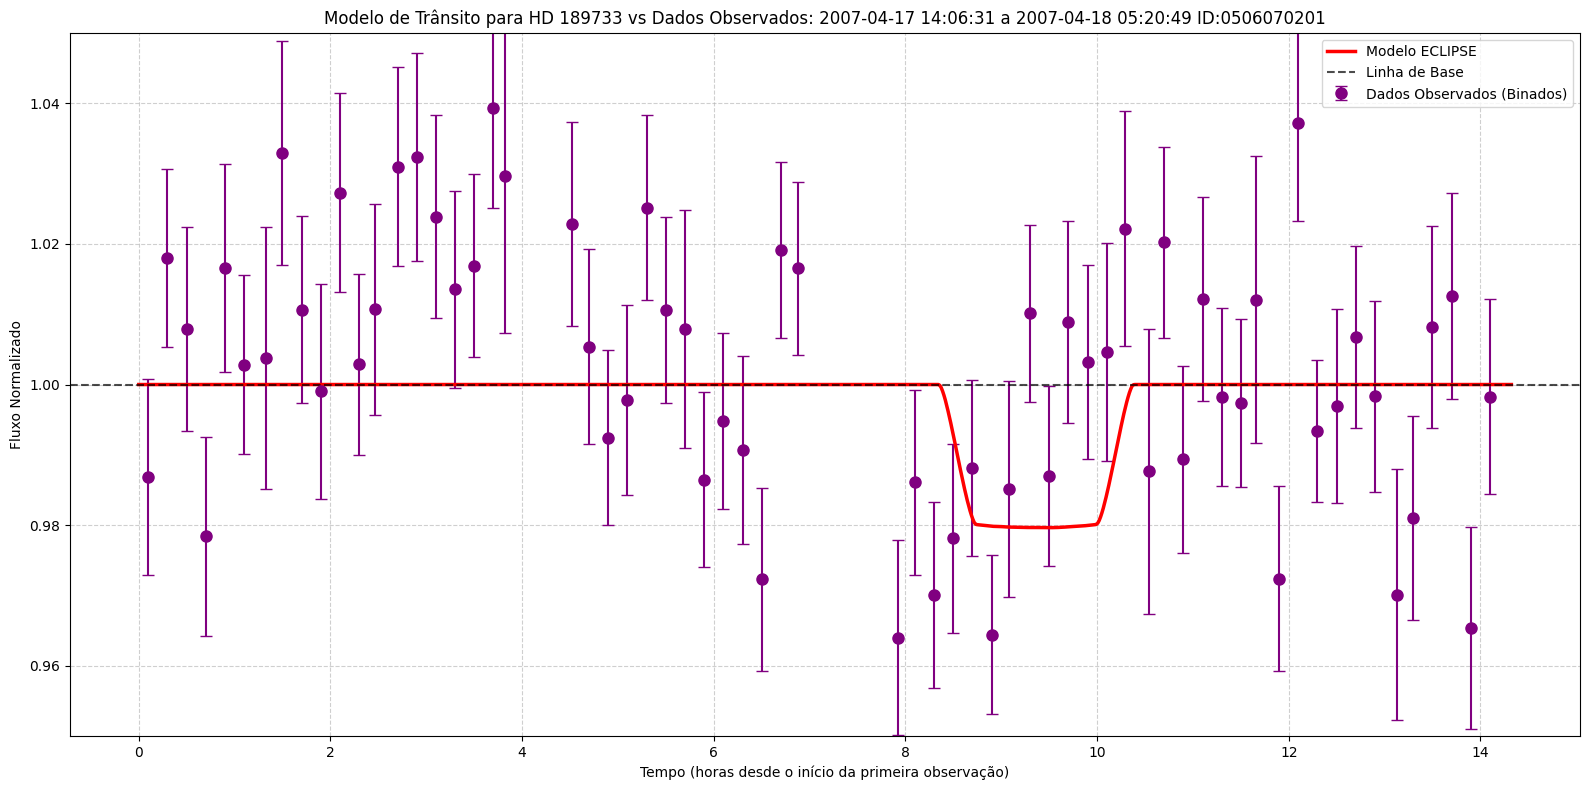

In [7]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2007-04-17 14:06:31 a 2007-04-18 05:20:49"
id_obs = "0506070201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/'
parametros_modelo['tC']= 9.5161 # Definindo a hora do centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 2) 2012-06-07 18:24:32 a 2012-06-08 11:29:48
0690890201

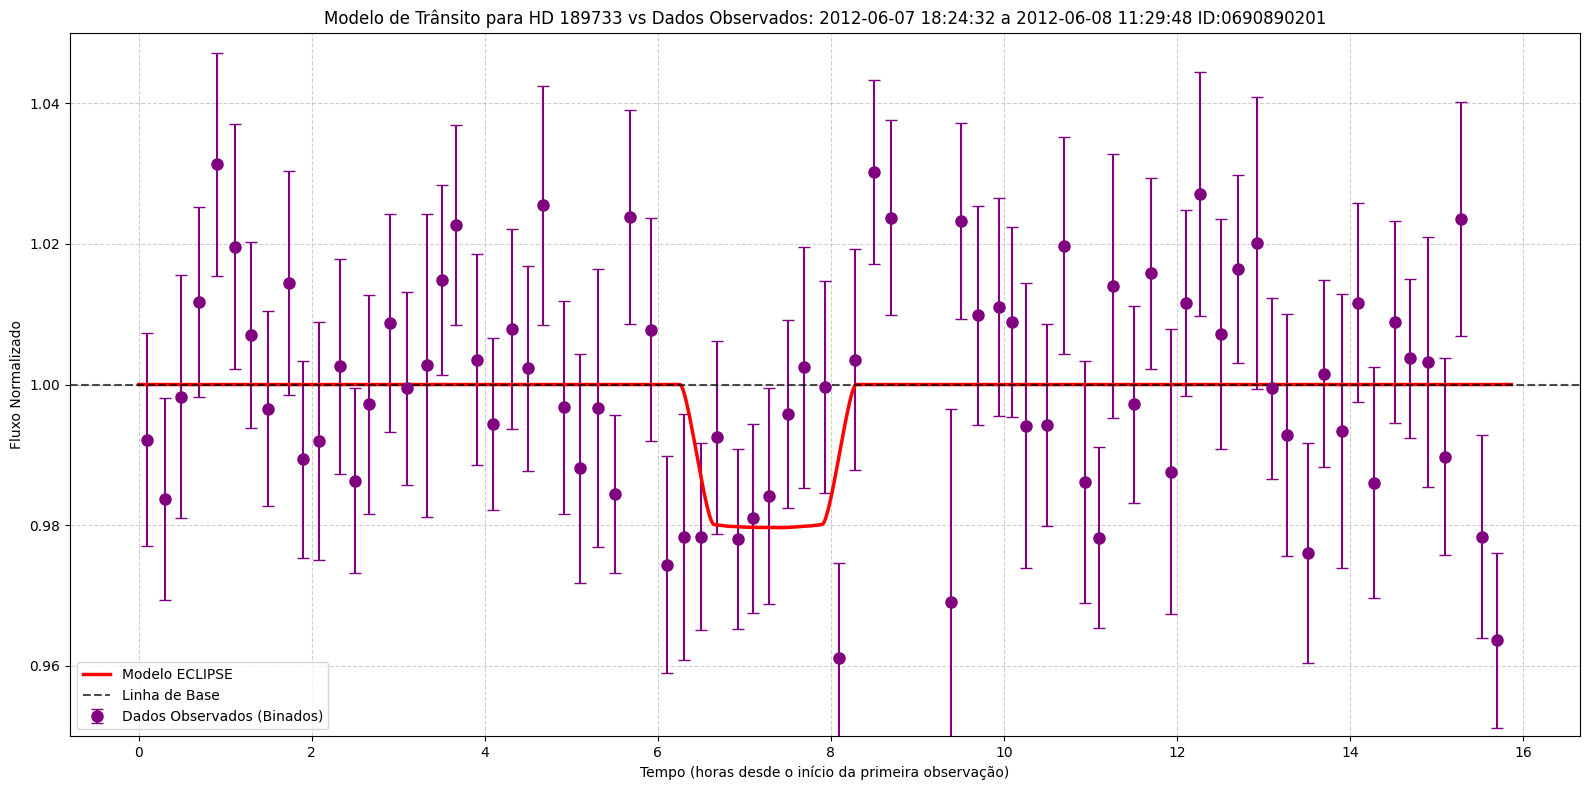

In [8]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2012-06-07 18:24:32 a 2012-06-08 11:29:48"
id_obs = "0690890201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/'
parametros_modelo['tC']= 7.4245 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 3) 2011-04-30 23:14:20 a 2011-05-01 10:06:12
0672390201

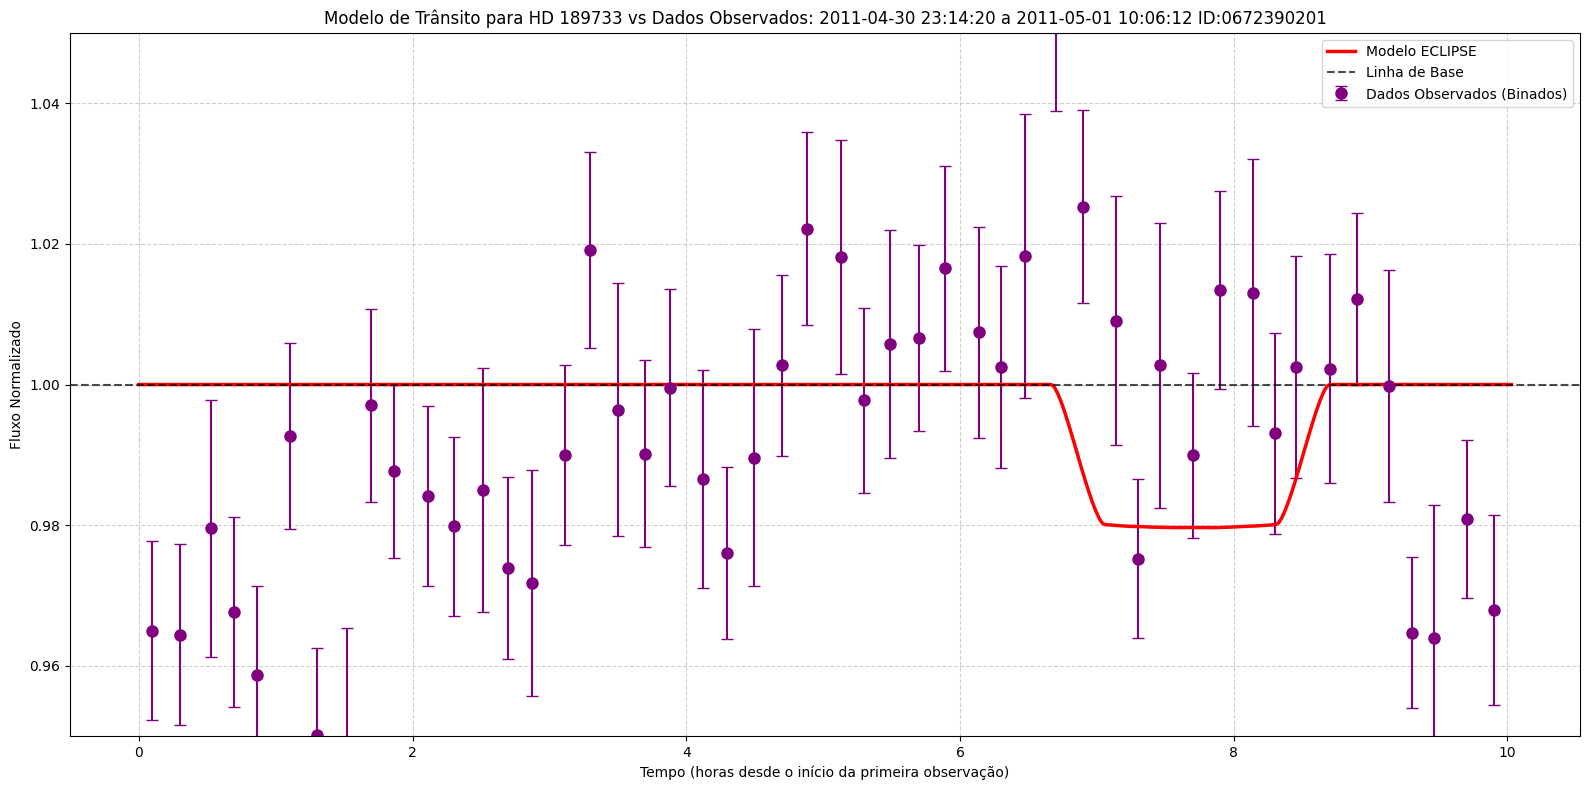

In [24]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2011-04-30 23:14:20 a 2011-05-01 10:06:12"
id_obs = "0672390201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/'
parametros_modelo['tC']= 7.8336 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados,0.2)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 4) 2014-11-13 06:46:05 a 2014-11-13 15:39:25
0744981401

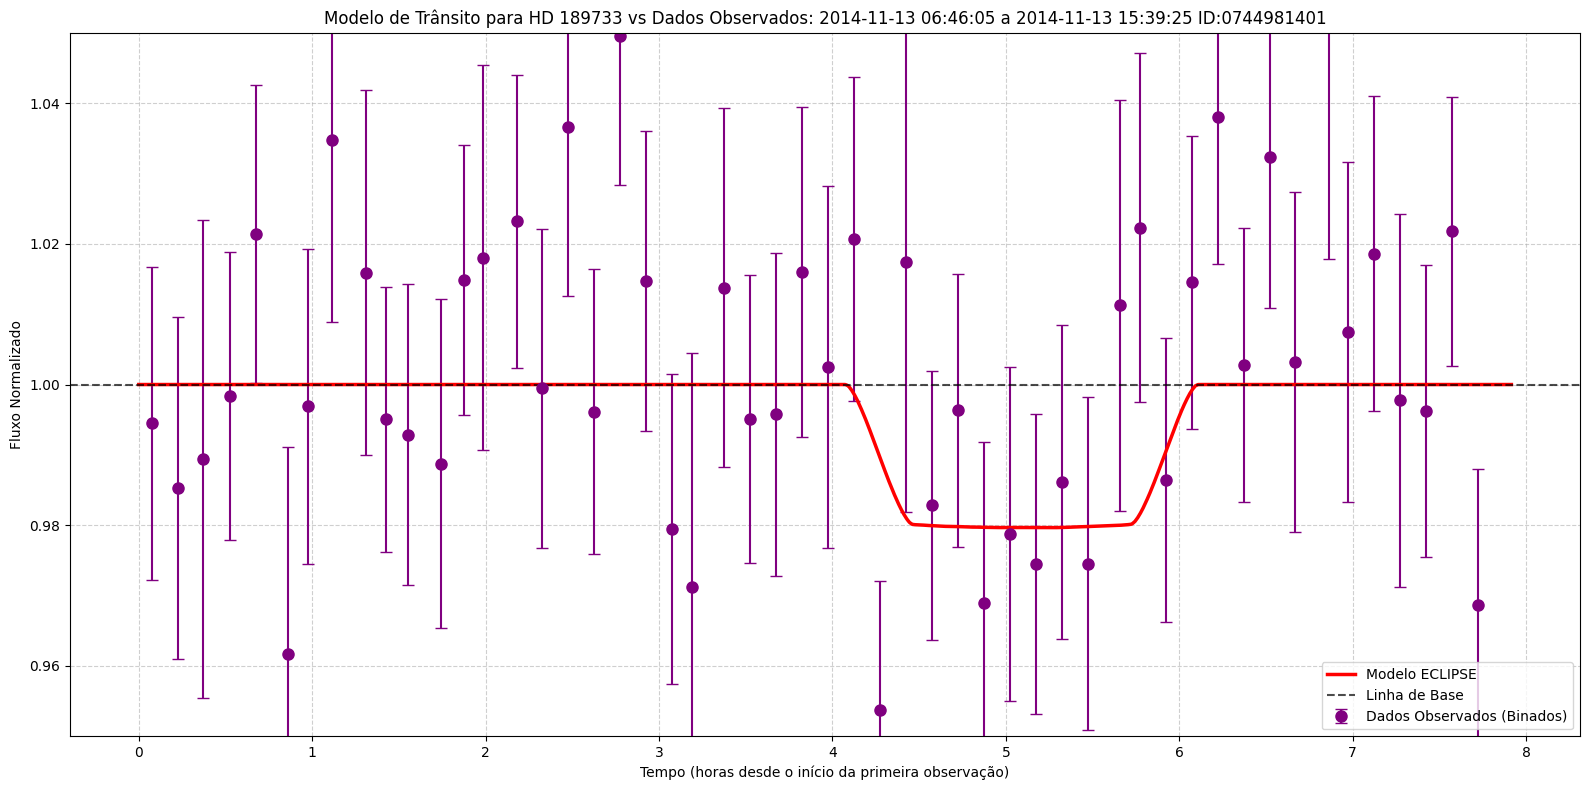

In [25]:
# 1. CARREGAR E PROCESSAR OS DADOS OBSERVADOS
date_obs = "2014-11-13 06:46:05 a 2014-11-13 15:39:25"
id_obs = "0744981401"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/'
parametros_modelo['tC']= 5.2427 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 5) 2015-04-17 12:34:55 a 2015-04-17 23:58:15
0744981601

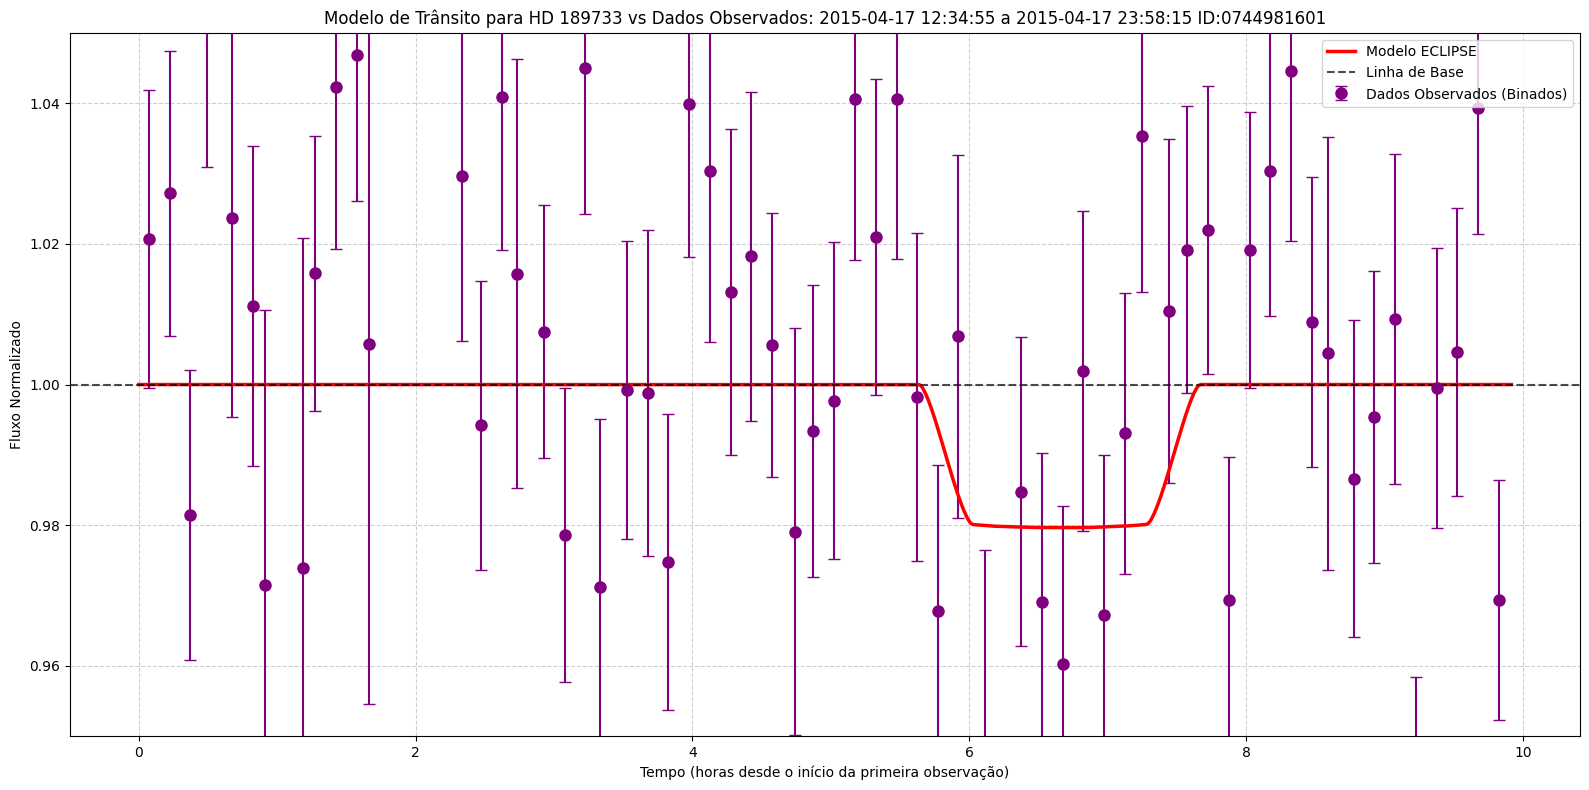

In [26]:
date_obs = "2015-04-17 12:34:55 a 2015-04-17 23:58:15"
id_obs = "0744981601"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981601/pps/'
parametros_modelo['tC']= 6.8033 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 6) 2015-04-19 19:06:26 a 2015-04-20 05:39:46
0744981701

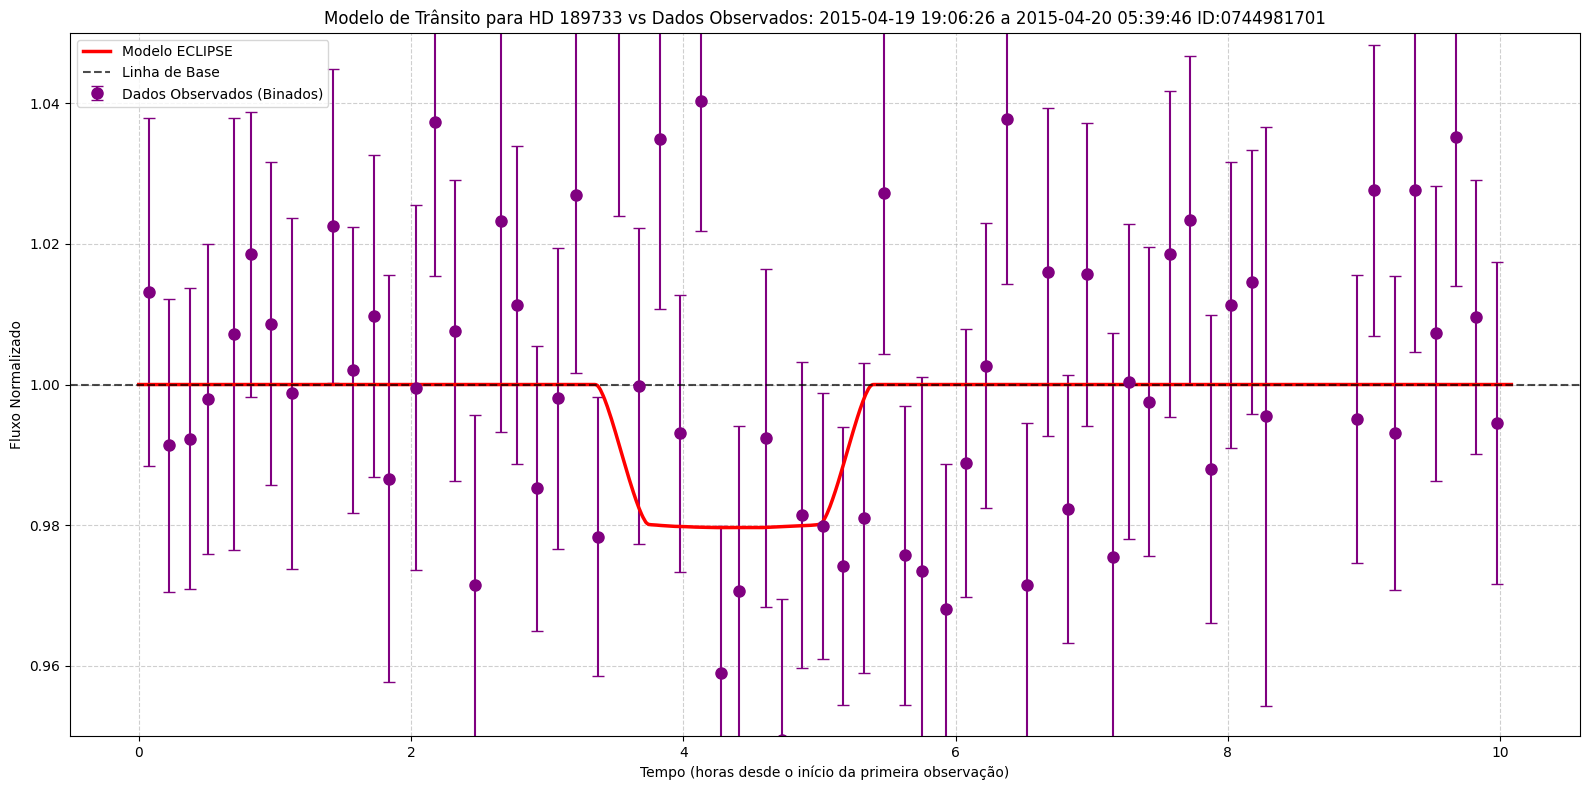

In [27]:
date_obs = "2015-04-19 19:06:26 a 2015-04-20 05:39:46"
id_obs = "0744981701"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981701/pps/'
parametros_modelo['tC']= 4.5239 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 7) 2014-10-17 16:08:26 a 2014-10-18 02:25:06
0744980801

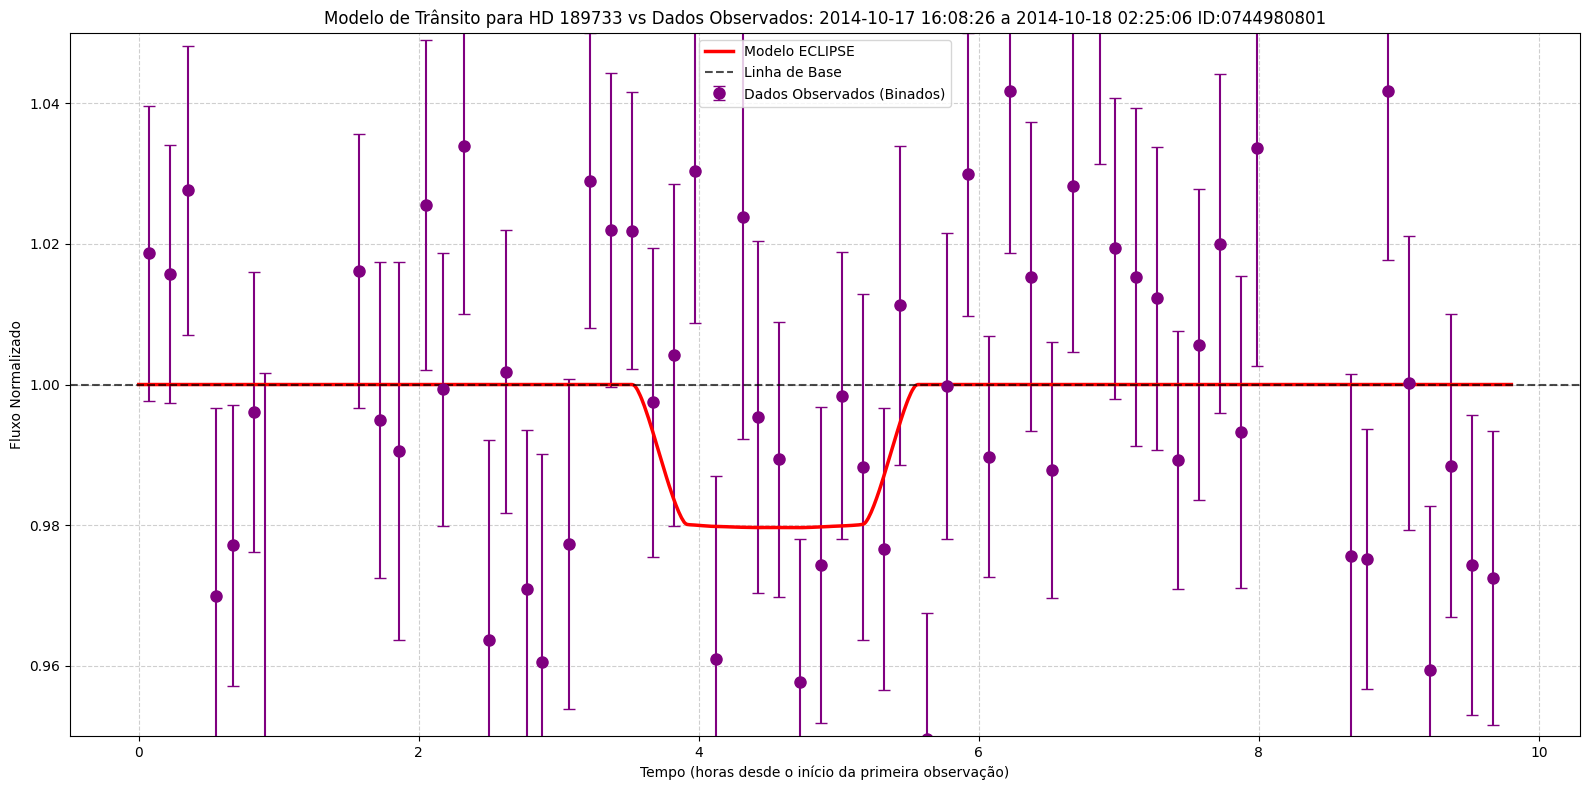

In [28]:
date_obs = "2014-10-17 16:08:26 a 2014-10-18 02:25:06"
id_obs = "0744980801"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980801/pps/'
parametros_modelo['tC']= 4.695 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 8) 2014-05-17 14:21:12 a 2014-05-17 23:14:32
0744980601

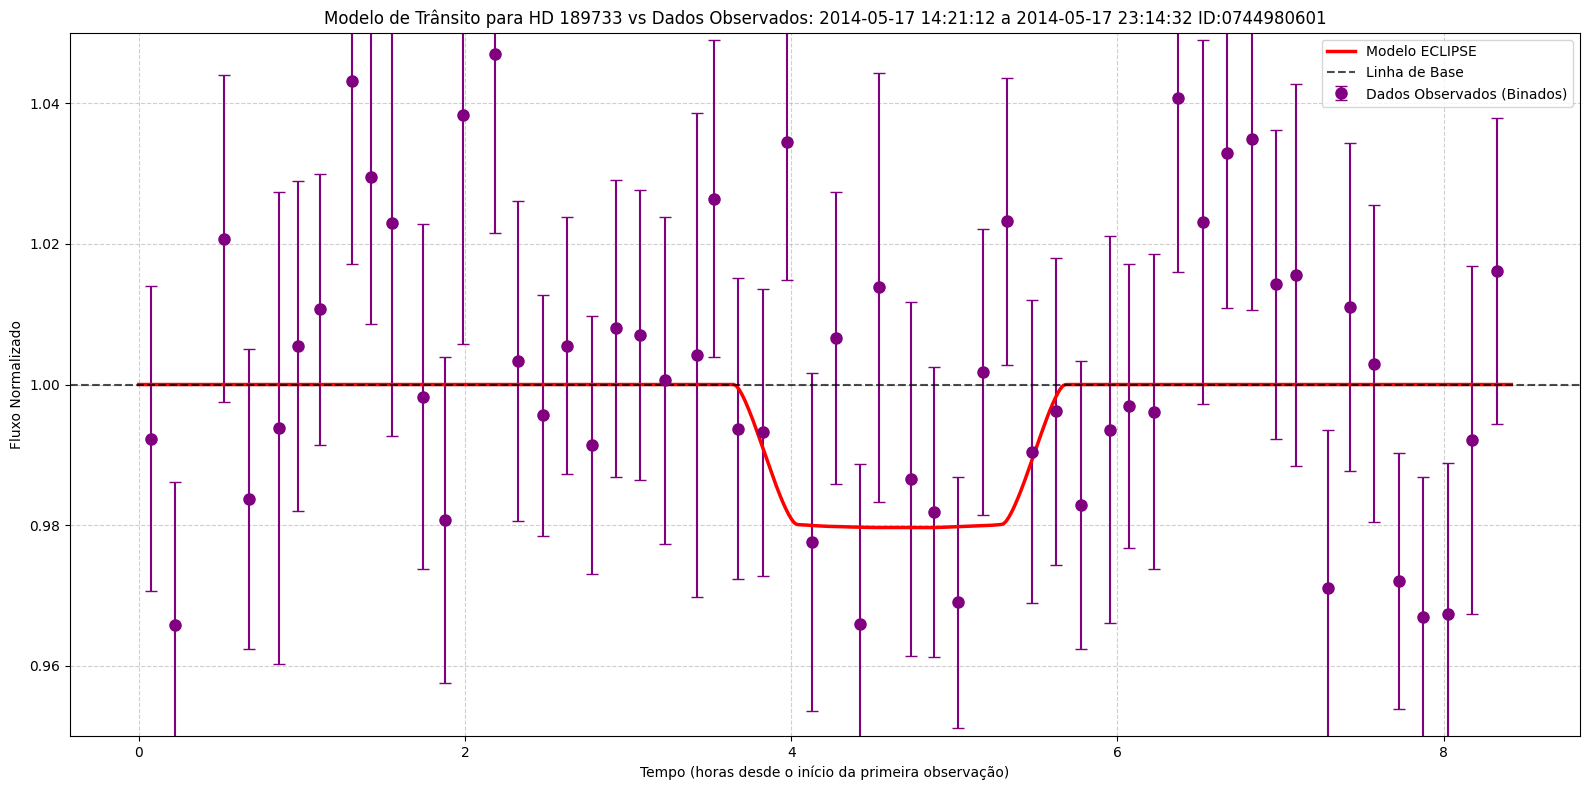

In [29]:
date_obs = "2014-05-17 14:21:12 a 2014-05-17 23:14:32"
id_obs = "0744980601"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980601/pps/'
parametros_modelo['tC']= 4.8147 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 9) 2014-11-11 00:37:26 a 2014-11-11 12:50:46
0744981201

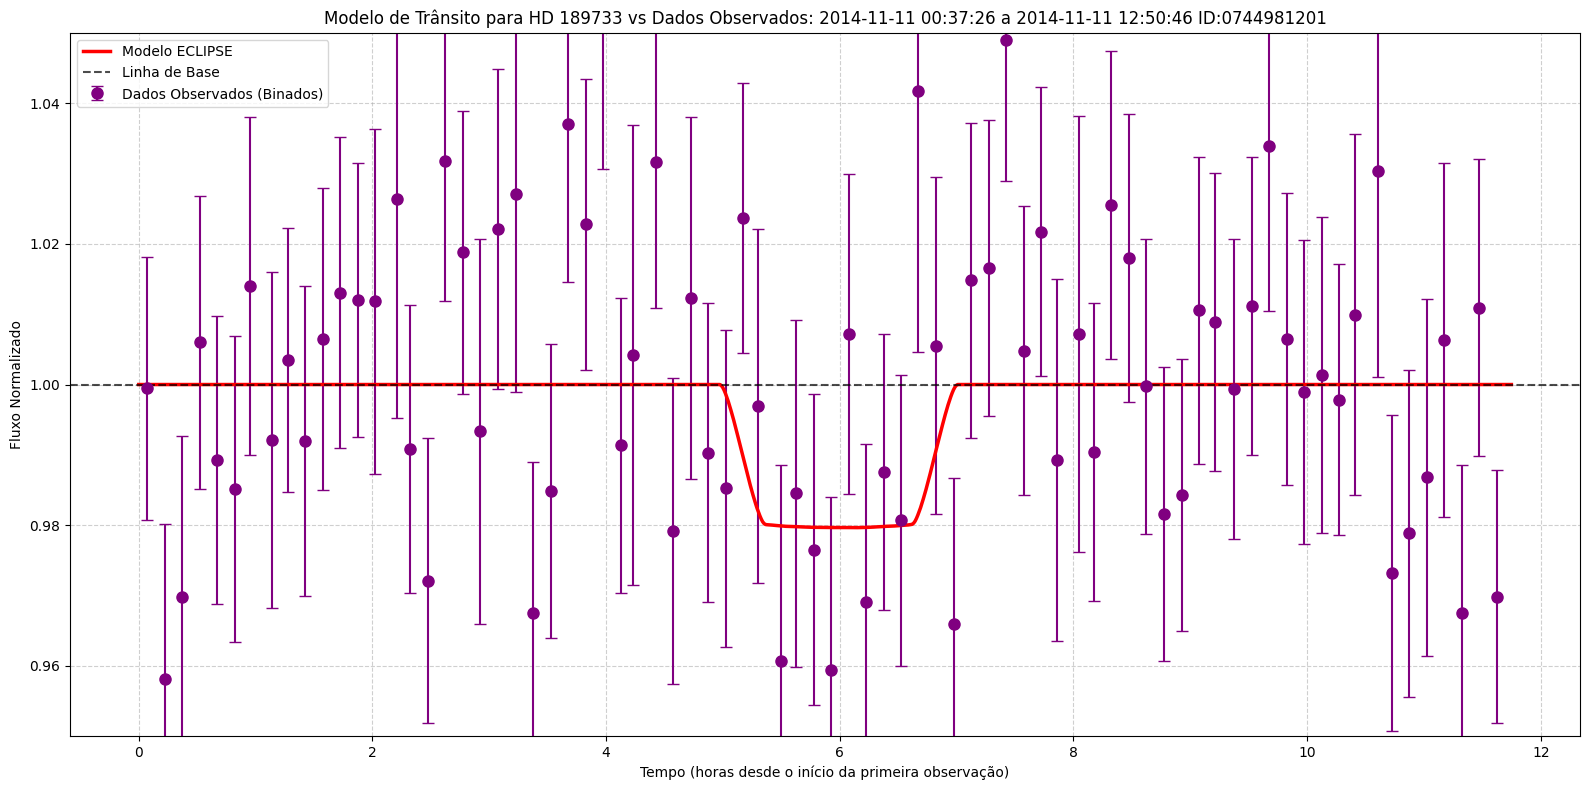

In [30]:
date_obs = "2014-11-11 00:37:26 a 2014-11-11 12:50:46"
id_obs = "0744981201"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981201/pps/'
parametros_modelo['tC']= 6.1414 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# 10) 2014-11-15 09:48:00 a 2014-11-15 20:38:00
0744980701

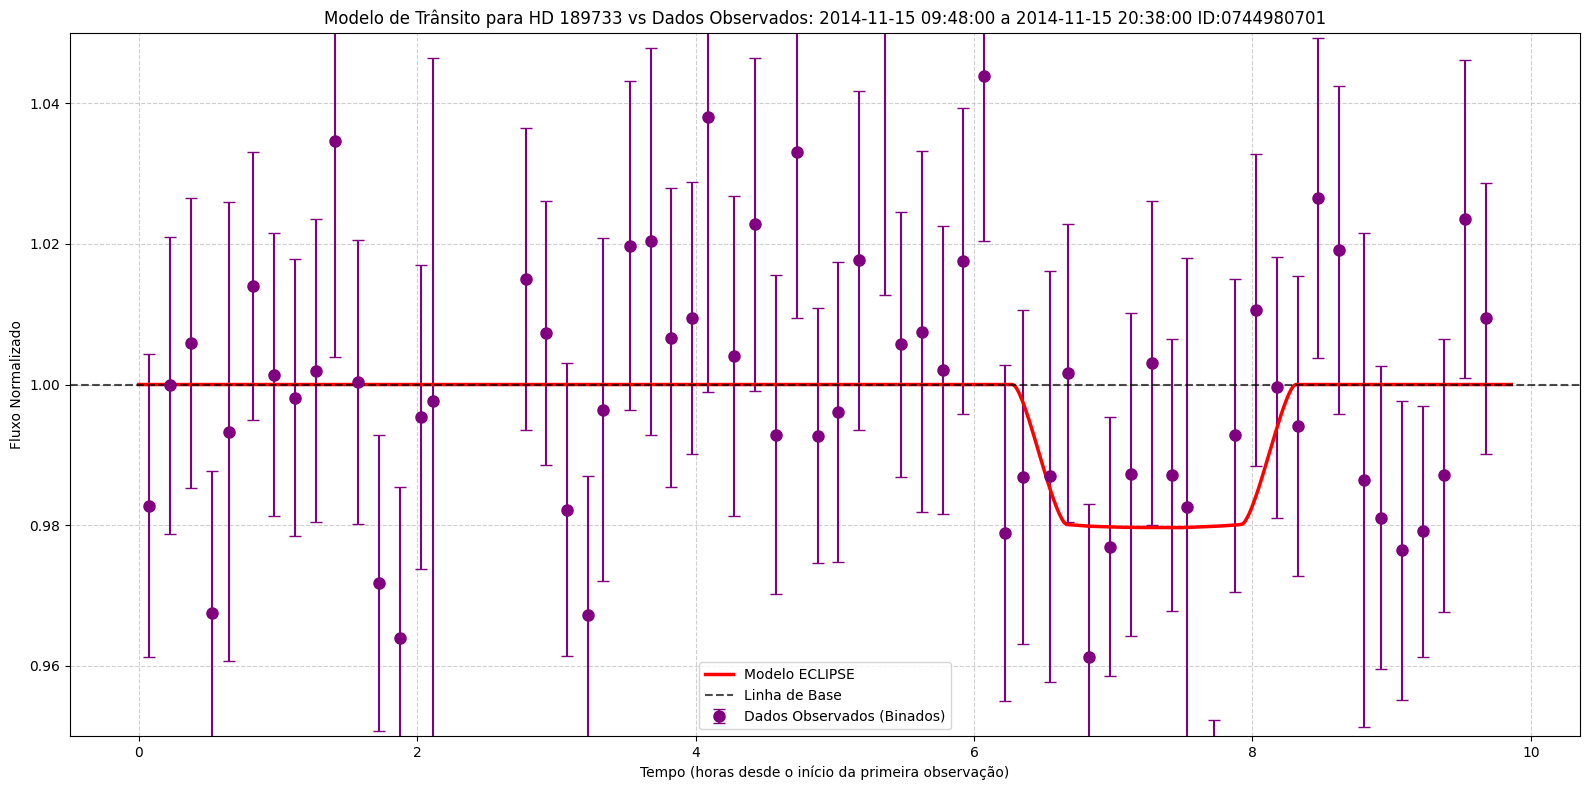

In [31]:
date_obs = "2014-11-15 09:48:00 a 2014-11-15 20:38:00"
id_obs = "0744980701"
pasta_dos_dados = '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980701/pps/'
parametros_modelo['tC']= 7.4447 # Definindo o centro do trânsito específico para essa análise

caminho_busca = os.path.join(pasta_dos_dados, padrao_arquivo)

lista_arquivos = glob.glob(caminho_busca)
tempos_em_horas, fluxos_normalizados = busca_fluxo_normalizado(lista_arquivos)

# Gerar o modelo para um tempo denso para uma linha suave
tempo_modelo_plot = np.linspace(tempos_em_horas.min(), tempos_em_horas.max(), 1000)

# Chamar a função que contém o SEU código para calcular o fluxo do modelo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_plot, parametros_modelo)

# 2. PLOTAGEM FINAL (Binning e Gráfico)
binned_time, binned_flux, binned_error = bin_data(tempos_em_horas, fluxos_normalizados, 0.15)

plot_lightcurve_and_model(binned_time, binned_flux, binned_error, tempo_modelo_plot, fluxo_do_seu_modelo, date_obs, id_obs)

# Média das curvas
Na análise à seguir estamos somando os 10 trânsitos observados e calculando sua média para utilizamos como base comparativa a fim de tentar mitigar ruídos extremos e outliers

In [7]:
def processar_curva_de_luz_para_empilhar(pasta_dados, t0_centro_transito, periodo_dias):
    """
    Função para carregar e processar uma curva de luz.
    Retorna os dados NÃO-BINADOS, mas já em fase orbital.
    """
    padrao_arquivo = '*OM*TIMESR*.FTZ'
    caminho_busca = os.path.join(pasta_dados, padrao_arquivo)
    lista_arquivos = glob.glob(caminho_busca)
    
    todos_tempos, todos_fluxos, todos_erros = [], [], []
    for arquivo in lista_arquivos:
        with fits.open(arquivo) as hdul:
            dados = hdul[1].data
            todos_tempos.extend(dados['TIME'])
            todos_fluxos.extend(dados['RATE'])
            todos_erros.extend(dados['ERROR'])
    
    todos_tempos, todos_fluxos, todos_erros = np.array(todos_tempos), np.array(todos_fluxos), np.array(todos_erros)
    indices_ordenados = np.argsort(todos_tempos)
    tempos_ordenados = todos_tempos[indices_ordenados]
    fluxos_ordenados = todos_fluxos[indices_ordenados]
    erros_ordenados = todos_erros[indices_ordenados]
    
    tempos_em_horas = (tempos_ordenados - tempos_ordenados[0]) / 3600.0
    
    mask_fora_transito = np.abs(tempos_em_horas - t0_centro_transito) > 1.5
    fluxo_fora_transito = np.mean(fluxos_ordenados[mask_fora_transito])
    fluxos_normalizados = fluxos_ordenados / fluxo_fora_transito
    erros_normalizados = erros_ordenados / fluxo_fora_transito
    
    periodo_em_horas = periodo_dias * 24.0
    fase_observada = (tempos_em_horas - t0_centro_transito) / periodo_em_horas
            
    return fase_observada, fluxos_normalizados, erros_normalizados

In [ ]:
def plotAverageLightCurve(ax, binned_fase, binned_flux, binned_error, 
                          fase_modelo_plot, fluxo_do_seu_modelo, 
                          observacoes, fig_name, language="PT"):
    # 1. Busca o dicionário do idioma, ignorando maiúsculas/minúsculas
    lang = language.upper()
    lang_data = TEXTS.get(lang, TEXTS["EN"])

    # 2. Plot dos dados binados
    ax.errorbar(
        binned_fase, binned_flux, yerr=binned_error,
        fmt='o', color='purple', markersize=6,
        ecolor='purple', capsize=0,
        label=lang_data["label_data"].format(n=len(observacoes))
    )

    # 3. Plot do modelo teórico
    ax.plot(
        fase_modelo_plot, fluxo_do_seu_modelo,
        color='red', linewidth=2.5, zorder=10,
        label=lang_data["label_model"]
    )

    # 4. Aplicação das legendas
    ax.set_title(lang_data["title_avg"], fontsize=16)
    ax.set_xlabel(lang_data["xlabel_avg"], fontsize=12)
    ax.set_ylabel(lang_data["ylabel_avg"], fontsize=12)

    # 5. Ajuste de escala e limites
    ax.set_xlim(-0.025, 0.025)
    ax.set_ylim(0.965, 1.035)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

    # 6. Gestão de diretórios
    output_dir = 'products'
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, f"{fig_name}.png")

    # 7. Salvamento e Finalização
    
    plt.tight_layout()
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {file_path}")
    plt.show()

 -> Processando 2007-04-17...
 -> Processando 2012-06-07...
 -> Processando 2011-05-01...
 -> Processando 2014-11-13...
 -> Processando 2015-04-17...
 -> Processando 2015-04-19...
 -> Processando 2014-10-1...
 -> Processando 2014-11-11...
 -> Processando 2014-05-17...
 -> Processando 2014-11-15...
Processamento concluído!
Gráfico salvo com sucesso em: products/average_lightcurve_hd189733.png


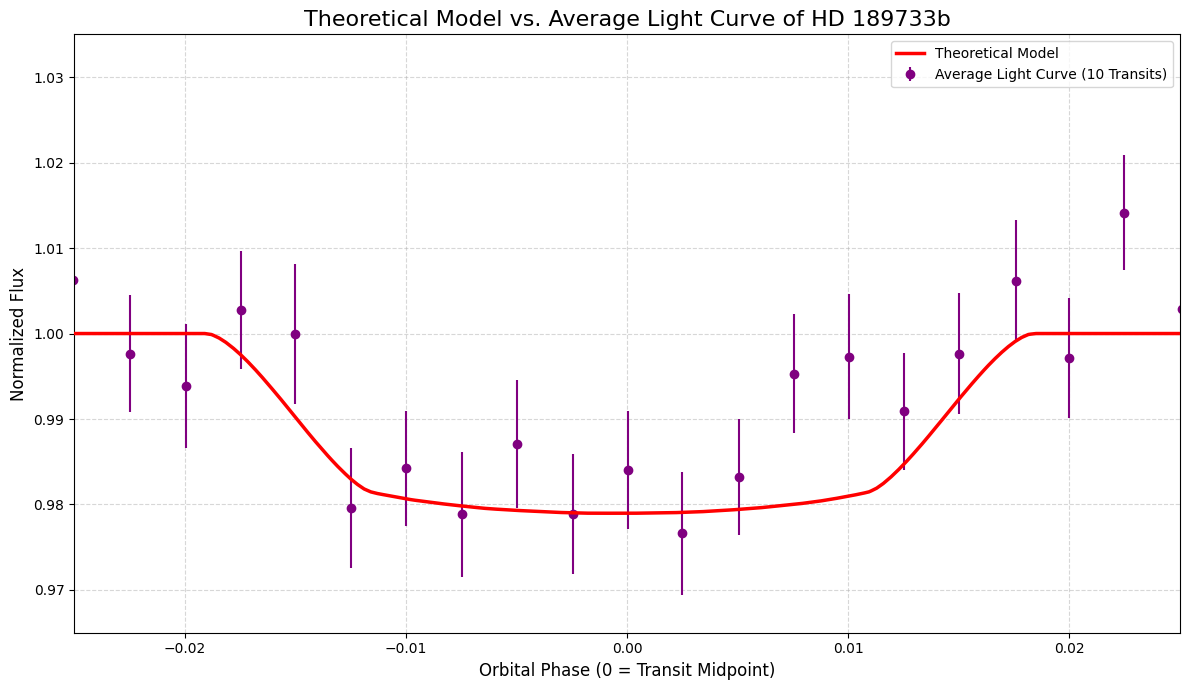

In [ ]:
# --- 1. CONFIGURAÇÃO ---
observacoes = [
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0506070201/pps/', 
        'tC': 9.5161,
        'label': '2007-04-17'
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0690890201/pps/',
        'tC': 7.4245,
        'label': '2012-06-07'
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0672390201/pps/', 
        'tC': 7.8336,
        'label': '2011-05-01' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981401/pps/', 
        'tC': 5.2427,
        'label': '2014-11-13' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981601/pps/', 
        'tC': 6.8033,
        'label': '2015-04-17' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981701/pps/', 
        'tC': 4.5239,
        'label': '2015-04-19' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980801/pps/', 
        'tC': 4.695,
        'label': '2014-10-1' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744981201/pps/', 
        'tC': 6.1414,
        'label': '2014-11-11' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980601/pps/', 
        'tC': 4.8147,
        'label': '2014-05-17' 
    },
    {
        'pasta': '/Users/beatrizduque/Downloads/Mestrado/HD189733/ligthcurves-om/0744980701/pps/', 
        'tC': 7.4447,
        'label': '2014-11-15' 
    },
]
periodo_geral_dias = 2.21857520

# --- 2. PROCESSAR E COMBINAR ---
todas_as_fases, todos_os_fluxos = [], []
for obs in observacoes:
    print(f" -> Processando {obs['label']}...")
    fase, fluxo, _ = processar_curva_de_luz_para_empilhar(obs['pasta'], obs['tC'], periodo_geral_dias)

    todas_as_fases.append(fase)
    todos_os_fluxos.append(fluxo)

print("Processamento concluído!")
fases_combinadas = np.concatenate(todas_as_fases)
fluxos_combinados = np.concatenate(todos_os_fluxos)

# --- 3. BINAR O CONJUNTO COMBINADO ---
bin_size_fase = 0.0025
bins = np.arange(fases_combinadas.min(), fases_combinadas.max(), bin_size_fase)
binned_fase, binned_flux, binned_error = [], [], []
for i in range(len(bins) - 1):
    mask = (fases_combinadas >= bins[i]) & (fases_combinadas < bins[i+1])
    if np.sum(mask) > 1:
        binned_fase.append(np.mean(fases_combinadas[mask]))
        binned_flux.append(np.mean(fluxos_combinados[mask]))
        n_points = len(fluxos_combinados[mask])
        binned_error.append(np.std(fluxos_combinados[mask]) / np.sqrt(n_points))

# --- 4. GERAR O MODELO TEÓRICO ---
parametros_modelo = {
    'rsun': 0.805, 
    'u1': 0.377, 
    'u2': 0.024, 
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.031, 
    'angulo_inclinacao': 85.51, 
    'periodo': periodo_geral_dias,
    'tC': 0.0 # O centro do nosso modelo é em t=0 horas, pois vamos plotar em fase
}

# Criar um eixo de fase suave para a linha do modelo
fase_modelo_plot = np.linspace(-0.025, 0.025, 1000)
# Converter o eixo de fase para um eixo de tempo em horas, centrado em zero
periodo_em_horas = periodo_geral_dias * 24.0
tempo_modelo_horas = fase_modelo_plot * periodo_em_horas
# Chamar sua função de modelo para gerar o fluxo
fluxo_do_seu_modelo = modelo_de_transito_eclipse(tempo_modelo_horas, parametros_modelo)

# --- 5. PLOTAGEM FINAL ---
fig, ax = plt.subplots(figsize=(12, 7))
plotAverageLightCurve(
    ax=ax,
    binned_fase=binned_fase,
    binned_flux=binned_flux,
    binned_error=binned_error,
    fase_modelo_plot=fase_modelo_plot,
    fluxo_do_seu_modelo=fluxo_do_seu_modelo,
    observacoes=observacoes,
    fig_name="average_lightcurve_hd189733",
    language="EN"
)

## Comparações com o modelo da média

O script à seguir permite comparar de forma individual cada trânsito com a média e com o modelo gerado, assim podemos identificar quais curvas de luz podem estar sendo afetadas por algum tipo de evento anômalo (no caso, uma possível CME)

In [31]:
def plotResidualAnalysis(ax_top, ax_bot, binned_fase_alvo, binned_fluxo_alvo, 
                         binned_erro_alvo, fase_media, fluxo_medio, erro_medio,
                         fase_modelo_plot, fluxo_do_seu_modelo, residuos, 
                         erro_residuos, obs_alvo, observacoes, 
                         qui_quadrado_reduzido, fig_name, language="PT"):
    # 1. Busca o dicionário do idioma, ignorando maiúsculas/minúsculas
    lang = language.upper()
    lang_data = TEXTS.get(lang, TEXTS["EN"])

    # 2. Painel superior: Comparação
    ax_top.errorbar(
        binned_fase_alvo, binned_fluxo_alvo, yerr=binned_erro_alvo,
        fmt='o', color='purple',
        label=lang_data["label_target"].format(label=obs_alvo["label"])
    )
    ax_top.errorbar(
        fase_media, fluxo_medio, yerr=erro_medio,
        fmt='o', color='black',
        label=lang_data["label_average"].format(n=len(observacoes))
    )
    ax_top.plot(
        fase_modelo_plot, fluxo_do_seu_modelo,
        color='red', linewidth=2.5, zorder=10,
        label=lang_data["label_model"]
    )
    ax_top.set_title(lang_data["title_comparison"])
    ax_top.set_ylabel(lang_data["ylabel_flux"])
    ax_top.grid(True, linestyle='--', alpha=0.6)
    ax_top.legend()

    # 3. Painel inferior: Resíduos
    ax_bot.errorbar(
        binned_fase_alvo, residuos, yerr=erro_residuos,
        fmt='o', color='crimson', markersize=5
    )
    ax_bot.axhline(0, color='black', linestyle='--')
    ax_bot.set_title(
        lang_data["title_residuals_panel"].format(chi2=qui_quadrado_reduzido)
    )
    ax_bot.set_xlabel(lang_data["xlabel_residuals"])
    ax_bot.set_ylabel(lang_data["ylabel_diff"])
    ax_bot.grid(True, linestyle='--', alpha=0.6)

    # 4. Gestão de diretórios
    output_dir = 'products'
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, f"{fig_name}.png")

    # 5. Salvamento e Finalização
    plt.xlim(-0.025, 0.025)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {file_path}")
    plt.show()

--------------------------------------------------
ANÁLISE ESTATÍSTICA DOS RESÍDUOS OBS 3
(Comparando a observação de 2011-05-01 com a média)
--------------------------------------------------
Valor do Qui-quadrado Reduzido (χ²ν): 1.8721
Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere
que a diferença entre esta observação e a média é maior que o ruído esperado.
==> Conclusão Numérica: Esta observação pode conter um evento anômalo.
--------------------------------------------------
Gráfico salvo com sucesso em: products/residual_analysis_hd189733.png


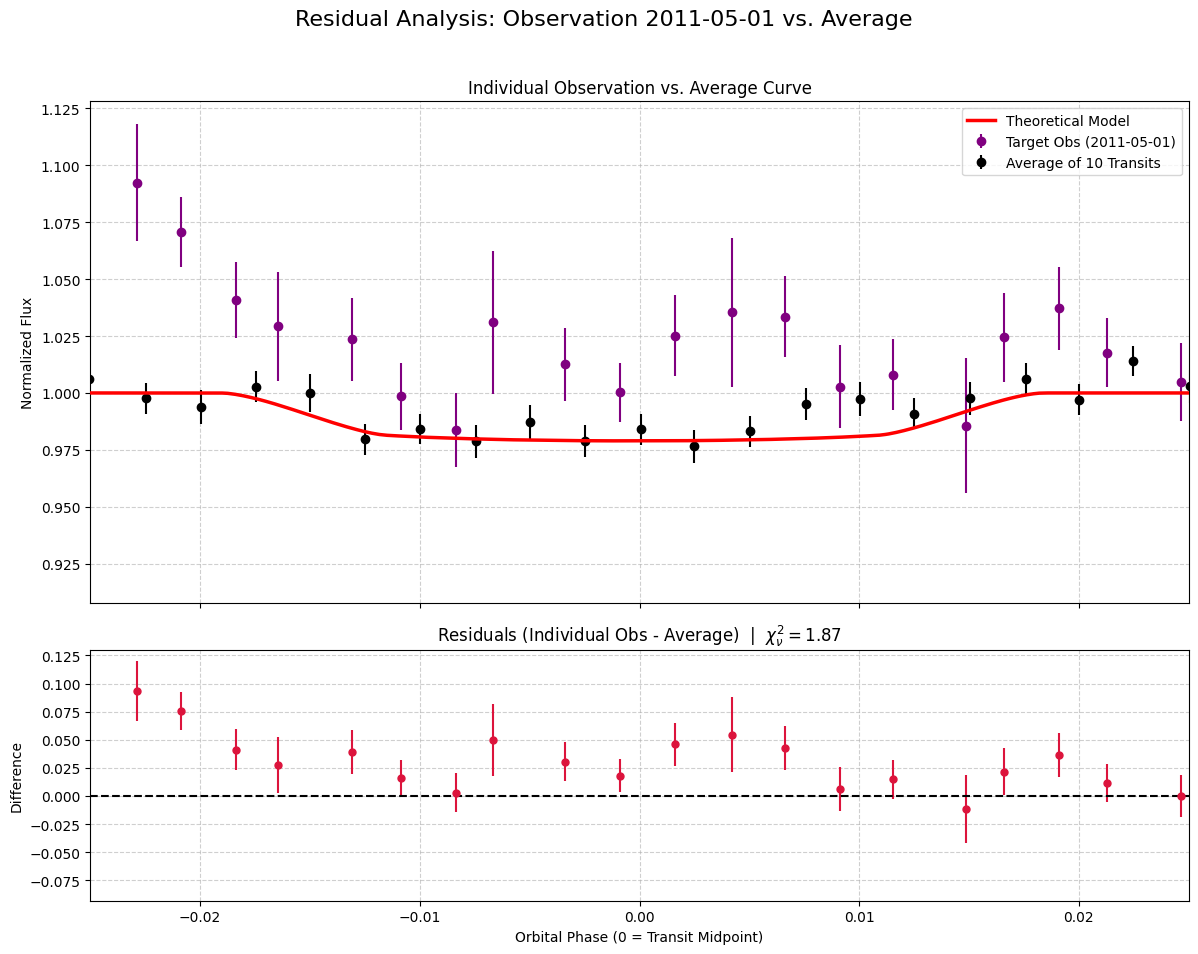

In [ ]:
periodo_geral_dias = 2.21857520

indice_da_obs_alvo = 5 # interessante 2 (obs 03) e 5 (obs 06)

fase_media, fluxo_medio, erro_medio = binned_fase, binned_flux, binned_error

# --- 3. PROCESSAR A OBSERVAÇÃO ALVO INDIVIDUALMENTE ---
obs_alvo = observacoes[indice_da_obs_alvo]
fase_alvo, fluxo_alvo, erro_alvo = processar_curva_de_luz_para_empilhar(obs_alvo['pasta'], obs_alvo['tC'], periodo_geral_dias)

# Binning da observação alvo para ter menos pontos
binned_fase_alvo, binned_fluxo_alvo, binned_erro_alvo = [], [], []
bins_alvo = np.arange(fase_alvo.min(), fase_alvo.max(), bin_size_fase)
for i in range(len(bins_alvo) - 1):
    mask = (fase_alvo >= bins_alvo[i]) & (fase_alvo < bins_alvo[i+1])
    if np.sum(mask) > 0: # > 0 para não perder bins com poucos pontos
        binned_fase_alvo.append(np.mean(fase_alvo[mask]))
        binned_fluxo_alvo.append(np.mean(fluxo_alvo[mask]))
        n_points = len(fluxo_alvo[mask])
        binned_erro_alvo.append(np.std(fluxo_alvo[mask]) / np.sqrt(n_points))
binned_fase_alvo, binned_fluxo_alvo, binned_erro_alvo = np.array(binned_fase_alvo), np.array(binned_fluxo_alvo), np.array(binned_erro_alvo)


# --- 4. SUBTRAIR A MÉDIA DA OBSERVAÇÃO ALVO ---
# Interpolar a curva média para os pontos de fase da observação alvo
fluxo_medio_interp = np.interp(binned_fase_alvo, fase_media, fluxo_medio)
erro_medio_interp = np.interp(binned_fase_alvo, fase_media, erro_medio)

# Calcular os resíduos
residuos = binned_fluxo_alvo - fluxo_medio_interp
erro_residuos = np.sqrt(binned_erro_alvo**2 + erro_medio_interp**2)

# --- 5. ANÁLISE ESTATÍSTICA DOS RESÍDUOS ---
modelo = np.zeros_like(residuos)
dados_observados = residuos
incerteza = erro_residuos
qui_quadrado = np.sum(((dados_observados - modelo) / incerteza)**2)
graus_de_liberdade = len(dados_observados) - 1
qui_quadrado_reduzido = qui_quadrado / graus_de_liberdade

print("-" * 50)
print("ANÁLISE ESTATÍSTICA DOS RESÍDUOS OBS", indice_da_obs_alvo+1)
print(f"(Comparando a observação de {obs_alvo['label']} com a média)")
print("-" * 50)
print(f"Valor do Qui-quadrado Reduzido (χ²ν): {qui_quadrado_reduzido:.4f}")

if 0.7 <= qui_quadrado_reduzido <= 1.5:
    print("Interpretação: Excelente! Um valor próximo de 1.0 indica que a diferença")
    print("entre esta observação e a média é consistente com o ruído esperado.")
    print("==> Conclusão Numérica: A observação alvo é estatisticamente 'normal'.")
elif qui_quadrado_reduzido > 1.5:
    print("Interpretação: Atenção. Um valor significativamente maior que 1.0 sugere")
    print("que a diferença entre esta observação e a média é maior que o ruído esperado.")
    print("==> Conclusão Numérica: Esta observação pode conter um evento anômalo.")
else: 
    print("Interpretação: Interessante. Um valor muito menor que 1.0 pode indicar")
    print("que as barras de erro dos dados foram superestimadas.")
print("-" * 50)

fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, 
                         gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(
    TEXTS[lang]["title_residuals"].format(label=obs_alvo["label"]), 
    fontsize=16
)

plotResidualAnalysis(
    ax_top=axs[0],
    ax_bot=axs[1],
    binned_fase_alvo=binned_fase_alvo,
    binned_fluxo_alvo=binned_fluxo_alvo,
    binned_erro_alvo=binned_erro_alvo,
    fase_media=fase_media,
    fluxo_medio=fluxo_medio,
    erro_medio=erro_medio,
    fase_modelo_plot=fase_modelo_plot,
    fluxo_do_seu_modelo=fluxo_do_seu_modelo,
    residuos=residuos,
    erro_residuos=erro_residuos,
    obs_alvo=obs_alvo,
    observacoes=observacoes,
    qui_quadrado_reduzido=qui_quadrado_reduzido,
    fig_name="residual_analysis_hd189733",
    language="EN"
)

## Aplicação de filtro (smooth)

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter

In [52]:
binned_fluxo_medio_smooth = savgol_filter(fluxo_medio, window_length=11, polyorder=3)
binned_fluxo_alvo_smooth = savgol_filter(binned_fluxo_alvo, window_length=11, polyorder=3)

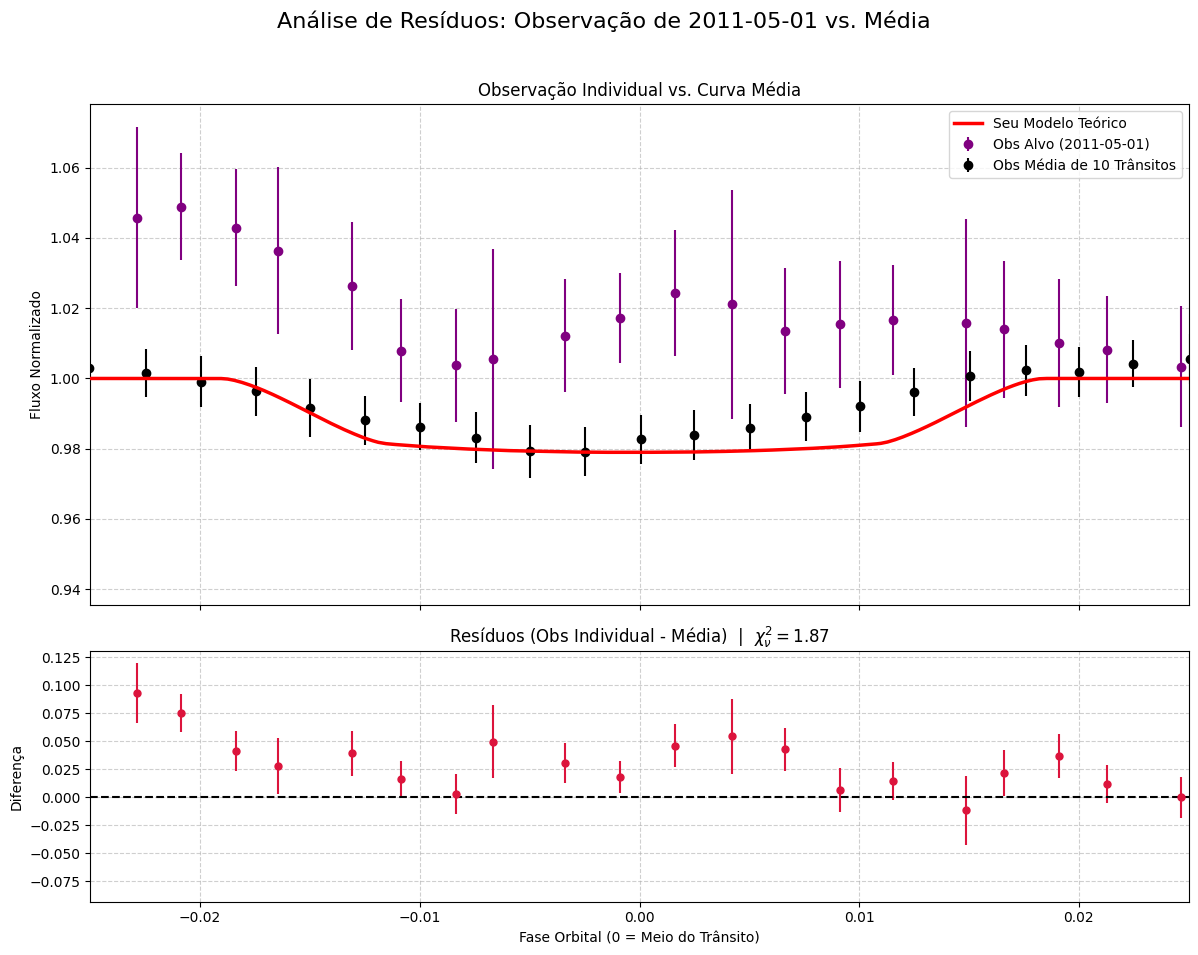

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'Análise de Resíduos: Observação de {obs_alvo["label"]} vs. Média', fontsize=16)

axs[0].errorbar(binned_fase_alvo, binned_fluxo_alvo_smooth, yerr=binned_erro_alvo, fmt='o', color='purple', label=f"Obs Alvo ({obs_alvo['label']})")
axs[0].errorbar(fase_media, binned_fluxo_medio_smooth, yerr=erro_medio, fmt='o', color='black', label=f"Obs Média de {len(observacoes)} Trânsitos")
axs[0].plot(fase_modelo_plot, fluxo_do_seu_modelo, color='red', linewidth=2.5, zorder=10, label='Modelo Teórico')

axs[0].set_title('Observação Individual vs. Curva Média')
axs[0].set_ylabel('Fluxo Normalizado')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

axs[1].errorbar(binned_fase_alvo, residuos, yerr=erro_residuos, fmt='o', color='crimson', markersize=5)
axs[1].axhline(0, color='black', linestyle='--')

axs[1].set_title(f'Resíduos (Obs Individual - Média)  |  $\\chi_\\nu^2 = {qui_quadrado_reduzido:.2f}$')
axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
axs[1].set_ylabel('Diferença')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.xlim(-0.025, 0.025)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

# MCMC

In [55]:
def filtrar_janela_numpy(x_arr, y_arr, limite):
    """
    Usa NumPy para zerar valores de y onde x está fora de [-limite, limite].
    """
    # Criamos uma cópia para preservar o array original
    y_novo = np.copy(y_arr)
    
    # Criamos a condição (máscara): onde x < -limite OU x > limite
    mask = (x_arr < -limite) | (x_arr > limite)
    
    # Aplicamos a máscara: onde a condição for True, y vira 0
    y_novo[mask] = 1.0
    
    return y_novo

In [57]:
from Localization.texts import TEXTS  # Importando sua variável do outro arquivo

def plotLegendModel(ax, mission, fig_name, language="PT"):
    # 1. Busca o dicionário do idioma, ignorando maiúsculas/minúsculas
    lang = language.upper()
    lang_data = TEXTS.get(lang, TEXTS["EN"])

    # 2. Aplicação das legendas
    # Usamos .format() porque a string lá no constants.py tem o marcador {mission}
    ax.set_title(lang_data["title"].format(mission=mission))
    ax.set_xlabel(lang_data["xlabel"])
    ax.set_ylabel(lang_data["ylabel"])

    # 3. Ajuste de escala e legenda
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin - (ymax - ymin) * 0.2, ymax) 
    ax.legend(loc='lower left')

    # 4. Gestão de diretórios (Moderno e limpo)
    output_dir = 'products'
    os.makedirs(output_dir, exist_ok=True)

    file_path = os.path.join(output_dir, f"{fig_name}.png")

    # 5. Salvamento e Finalização
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo com sucesso em: {file_path}")
    plt.show()

### Valores já ajustados pelo script main-mcmc.ipynb

In [58]:
# Modelo original
parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.520,
    'u2': 0.082,
    'raio_plan_Jup': 1.107,
    'semi_eixo_UA': 0.043,
    'angulo_inclinacao': 88.526,
    'periodo': 2.21857520,
    'mass_planeta': 1.138,
    # Parâmetro medido dos dados para alinhamento
    'tC': 1 # Centro do trânsito default
}

parametros_modelo = {
    'rsun': 0.805,
    'u1': 0.0618,
    'u2': 0.0204,
    'raio_plan_Jup': 1.138,
    'semi_eixo_UA': 0.0401,
    'angulo_inclinacao': 85.526,
    'periodo': 2.21857520,
    'mass_planeta': 1.138,
    # Parâmetro medido dos dados para alinhamento
    'tC': 1 # Centro do trânsito default
}

In [59]:
# Parâmetros resultados no primeiro mcmc 
u1 = parametros_modelo['u1']
u2 = parametros_modelo['u2']
semi_eixo_UA = parametros_modelo['semi_eixo_UA']
angulo_inclinacao = parametros_modelo['angulo_inclinacao']
raio_plan_Jup = parametros_modelo['raio_plan_Jup']

estrela_ = Estrela(373, parametros_modelo['rsun'], 240., u1, u2, 856)
estrela_.setStarName("HD189733 A")
estrela_.setCadence("fast")

Nx = estrela_.getNx()
Ny = estrela_.getNy()
raioEstrelaPixel = estrela_.getRaioStar()

planeta_= Planeta(semi_eixo_UA, raio_plan_Jup, parametros_modelo['periodo'], angulo_inclinacao, 0, 0, estrela_.getRaioSun(), parametros_modelo['mass_planeta'])

eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_)
eclipse.setTempoHoras(5) 


## Observação modelo vs curva média de 10 trânsitos

0.3196070194244385


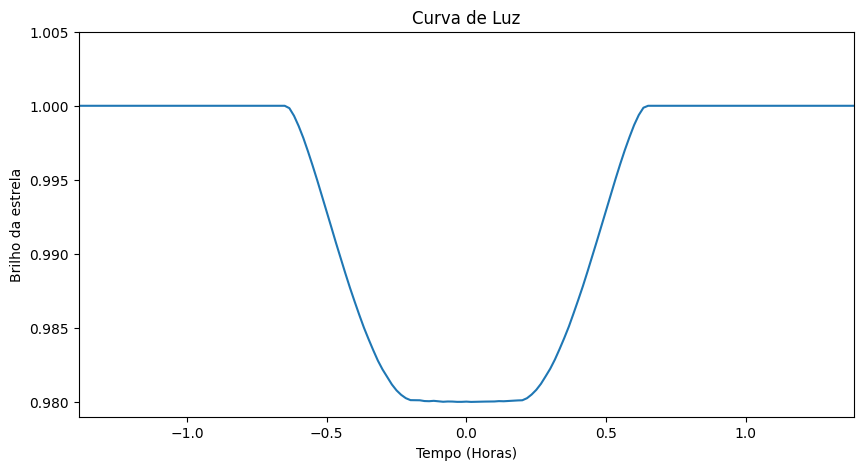

Tempo Total (Trânsito): 2.7724755682619966


In [60]:
#eclipse
estrela_matriz = estrela_.getMatrizEstrela()
eclipse.setEstrela(estrela_matriz)
eclipse.criarEclipse(anim=False)

print ("Tempo Total (Trânsito):", eclipse.getTempoTransito()) 
tempoTransito = eclipse.getTempoTransito()
curvaLuz = eclipse.getCurvaLuz()
tempoHoras = eclipse.getTempoHoras()

Gráfico salvo com sucesso em: products/lightcurve-vs-model.png


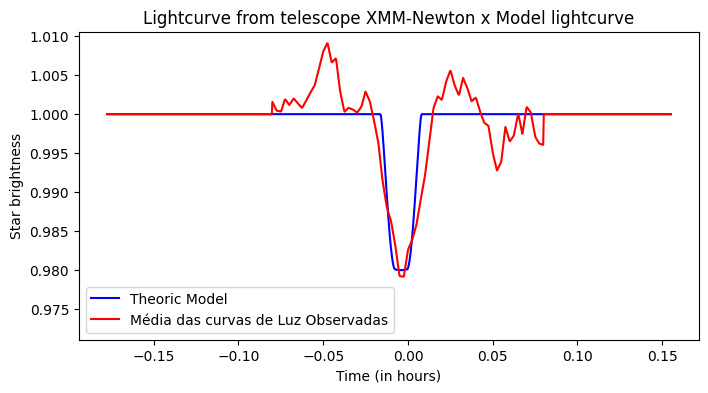

In [61]:
lc_modelo_raw = np.array(eclipse.getCurvaLuz()) 
tempo_modelo_raw_horas = np.array(eclipse.getTempoHoras())

# --- 2. ALINHAR O MODELO EM FASE ORBITAL ---
lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
meio_transito_no_modelo_horas = tempo_modelo_raw_horas[np.argmin(lc_modelo_normalizado)]
tempo_modelo_centralizado = tempo_modelo_raw_horas - meio_transito_no_modelo_horas
periodo_em_horas = periodo_geral_dias * 24.0
fase_do_modelo = (tempo_modelo_centralizado - 0.2) / periodo_em_horas #ajustar aqui o centro

# --- 3. INTERPOLAR AMBAS AS CURVAS PARA UM EIXO COMUM ---
# Primeiro, garantimos que as listas dos dados observados sejam arrays NumPy
#binned_fase_alvo, binned_fluxo_medio_smooth
fase_media = np.array(fase_media)
binned_fluxo_medio_smooth = np.array(binned_fluxo_medio_smooth)
# -----------------------------

fase_plot_final = np.linspace(fase_media.min(), fase_media.max(), 1000)

# Mapeamos (interpolamos) a curva de luz observada para o novo eixo
fluxo_medio_observado_interp = np.interp(fase_plot_final, fase_media, binned_fluxo_medio_smooth)
# Mapeamos (interpolamos) a curva de luz do seu modelo para o novo eixo
fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)

# --- 4. PLOTAGEM FINAL CORRIGIDA ---
plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

mission = "XMM-Newton"

fluxo_modelo_interp = np.array(fluxo_modelo_interp)
fluxo_medio_observado_interp = np.array(fluxo_medio_observado_interp)
fluxo_modelo_interp = fluxo_modelo_interp + (1 - fluxo_modelo_interp[0])

fluxo_medio_observado_interp_filtrado = filtrar_janela_numpy(fase_plot_final, fluxo_medio_observado_interp, 0.08)

ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Theoric Model')
ax.plot(fase_plot_final, fluxo_medio_observado_interp_filtrado, "r-", label='Média das curvas de Luz Observadas')

plotLegendModel(ax, mission,"lightcurve-vs-model", "EN") 

### Extração de Ruído

resultado = curva_luz_manchada - curva_luz_nao_manchada

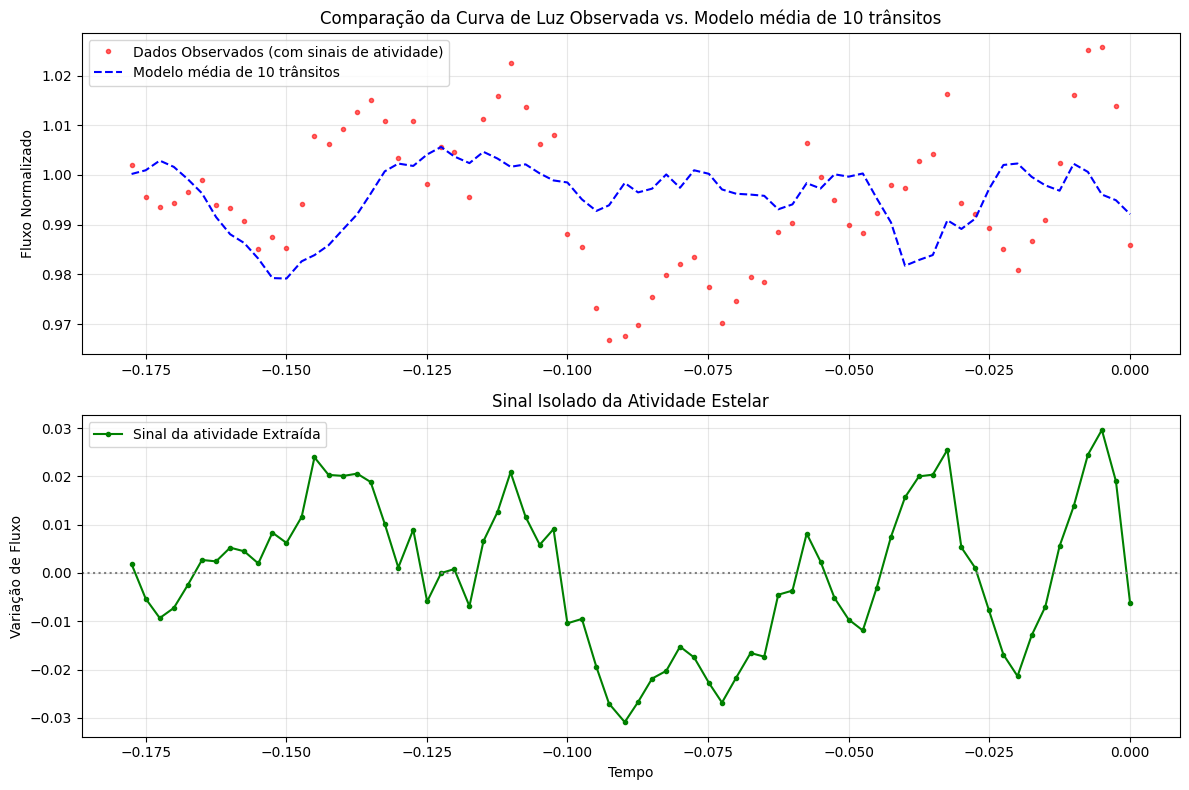

In [410]:
tempo = fase_media[:72]
curva_luz_manchada = binned_fluxo_alvo_smooth # fluxo alvo definido como aquele que apresentou maior sinal anômalo
curva_luz_nao_manchada = binned_fluxo_medio_smooth[59:131]

# --- Passo 2: Aplicar lógica de subtração ---
sinal_da_mancha = curva_luz_manchada - curva_luz_nao_manchada

# --- Passo 3: Visualizar os resultados ---
plt.figure(figsize=(12, 8))

# Plot 1: Comparação das curvas de luz
plt.subplot(2, 1, 1)
plt.plot(tempo, curva_luz_manchada, '.', label='Dados Observados (com sinais de atividade)', color='red', alpha=0.6)
plt.plot(tempo, curva_luz_nao_manchada, label='Modelo média de 10 trânsitos', color='blue', linestyle='--')
plt.title('Comparação da Curva de Luz Observada vs. Modelo média de 10 trânsitos')
plt.ylabel('Fluxo Normalizado')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Sinal da mancha extraído
plt.subplot(2, 1, 2)
plt.plot(tempo, sinal_da_mancha, '.-', label='Sinal da atividade Extraída', color='green')
plt.axhline(0, color='grey', linestyle=':')
plt.title('Sinal Isolado da Atividade Estelar')
plt.xlabel('Tempo')
plt.ylabel('Variação de Fluxo')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Simulação de ruídos

### Justificativa Física para Alteração de Parâmetros (Modelo com CME)

Ao introduzir a simulação de uma Ejeção de Massa Coronal (CME) através do método de *coronal dimming*, o algoritmo de ajuste (script `ECLIPSE`) realiza compensações nos parâmetros planetários nominais para manter a consistência com a curva de luz observada.

## 1. Redução do Raio Planetário (`raio_plan_Jup`: 1.138 -> 0.93)
Esta é a alteração de maior impacto físico no modelo.
* **Compensação de Área**: A CME é modelada como uma região de brilho reduzido que obstrui parte da luz estelar.
* **Profundidade do Trânsito**: Se o raio original do planeta fosse mantido em conjunto com a área de *dimming* da CME, a profundidade total do trânsito na simulação excederia os valores observados nos dados reais.
* **Conclusão**: O algoritmo reduz o raio do planeta para compensar a área "extra" de escurecimento gerada pela CME, provando que o fenômeno eruptivo contribui significativamente para a queda de luminosidade detectada.

## 2. Ajuste de Oscurecimento de Limbo (`u1`, `u2`: -> 1.0)
* **Ajuste de Contraste**: Ao maximizar os coeficientes de oscurecimento de limbo, o modelo aumenta o contraste entre o centro e as bordas da estrela.
* **Contexto de Atividade**: Em estrelas altamente ativas como a HD 189733 A, essa mudança ajuda a isolar a assinatura da CME frente ao ruído e à luminosidade da fotosfera, permitindo que a região de *dimming* seja estatisticamente relevante no ajuste.

## 3. Inclinação (`angulo_inclinacao`: 85.526 -> 88.526) e Período (`periodo`: 2.21 -> 2.31)
* **Escala Espacial e Temporal**: Diferente do planeta, a CME é uma estrutura em expansão que pode ocupar uma área maior e durar mais tempo que o trânsito geométrico convencional.
* **Geometria de Observação**: O aumento da inclinação (tornando o trânsito mais central) e do período (aumentando a duração) permite que o modelo alinhe a trajetória do planeta exatamente sobre a estrutura de **Cápsula** ou **Gota** da CME.
* **Validação**: Essas alterações confirmam que o sinal anômalo possui uma assinatura temporal que extrapola os limites de um planeta isolado, sendo compatível com um evento de alta energia ($\approx 1,8 \times 10^{34}$ erg).

---
**Resumo Científico**: As variações nos parâmetros nominais demonstram que a atividade estelar intensa da HD 189733 A distorce a determinação de propriedades planetárias. No contexto deste estudo, tais mudanças são evidências matemáticas necessárias para isolar a física da Ejeção de Massa Coronal na curva de luz.

In [64]:
parametros_modelo = {
    'rsun': 0.805,
    'u1': 1,
    'u2': 1,
    'raio_plan_Jup': 0.99, #ou 0.95
    'semi_eixo_UA': 0.0401,
    'angulo_inclinacao': 88.526,
    'periodo': 2.31857520,
    'mass_planeta': 1.138,
    # Parâmetro medido dos dados para alinhamento
    'tC': 1 # Centro do trânsito default
}

# Parâmetros resultados no primeiro mcmc 
u1 = parametros_modelo['u1']
u2 = parametros_modelo['u2']
semi_eixo_UA = parametros_modelo['semi_eixo_UA']
angulo_inclinacao = parametros_modelo['angulo_inclinacao']
raio_plan_Jup = parametros_modelo['raio_plan_Jup']

estrela_ = Estrela(373, parametros_modelo['rsun'], 240., u1, u2, 856)
estrela_.setStarName("HD189733 A")
estrela_.setCadence("fast")

Nx = estrela_.getNx()
Ny = estrela_.getNy()
raioEstrelaPixel = estrela_.getRaioStar()

planeta_= Planeta(semi_eixo_UA, raio_plan_Jup, parametros_modelo['periodo'], angulo_inclinacao, 0, 0, estrela_.getRaioSun(), parametros_modelo['mass_planeta'])

eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_)
eclipse.setTempoHoras(5) 

### Mancha - modelo convencional

In [63]:
# mancha
raio_mancha = 0.20
intensidade = 0.5 
latitude = -15
longitude = 5

raio_mancha2 = 0.30
intensidade2 = 0.5 
latitude2 = -15
longitude2 = 8

mancha = Estrela.Mancha(intensidade, raio_mancha, latitude, longitude)
mancha2 = Estrela.Mancha(intensidade2, raio_mancha2, latitude2, longitude2) 


estrela_.addMancha(mancha)
estrela_.addMancha(mancha2)

# flare
raio_flare = 0.15
intensidade_flare = 1.5
latitude_flare = -15
longitude_flare = -15

facula = Estrela.Facula(intensidade_flare, raio_flare, latitude_flare, longitude_flare)


estrela_.addFacula(facula)

estrela_.criaEstrelaManchada()
estrela_matriz = estrela_.getMatrizEstrela()

### Flare - moodelo convencional

In [103]:
# add flare
raio_flare = 0.26
intensidade_flare = 1.6
latitude_flare = -39
longitude_flare = -28

flare = Estrela.Facula(intensidade_flare, raio_flare, latitude_flare, longitude_flare)
#facula2 = Estrela.Facula(1.5, 0.08, latitude_facula, longitude_facula) #caso queira adicionar mais fáculas


estrela_.addFacula(flare)
#estrela_.addFacula(facula2)

estrela_.criaEstrelaComFaculas()
estrela_matriz = estrela_.getMatrizEstrela()

## CME - proposta de modelo

In [65]:
projecao_selecionada = GeometriaCME.PROJECAO_DISCO

### CME Cápsula

In [66]:
estrela_matriz = estrela_.getMatrizEstrela()

### Capsula
intensidade_cme = estrela_.temperaturaEfetiva-800 # temperatura da CME (em K) 4875.0
raio_cme = 110 # pixel
velocidade_cme = 0.152506053839219 # UA/h 
altura_inicial_cme = -1 # Em UA (valores negativos muito altos servem para simular a CME não alcançando a atmosfera do planeta)
opacidade = 0.4289613239247936
taxa_escurecimento = 120.01068829123473
p0x = 291
p0y = 200
p1x = 201
p1y = 271

cme = Estrela.EjecaoMassa(raio_cme, p0x, p0y, p1x, p1y, opacidade, intensidade_cme, velocidade_cme, taxa_escurecimento, altura_inicial_cme, GeometriaCME.PROJECAO_DISCO)

estrela_.addCme(cme)

### CME Gota maior massa

In [67]:
estrela_matriz = estrela_.getMatrizEstrela()

### Gota maior massa
intensidade_cme = estrela_.temperaturaEfetiva-800 # temperatura da CME (em K) 4875.0
raio_cme = 90 # pixel
velocidade_cme = 0.15327006832062182 # UA/h 
altura_inicial_cme = -1 # Em UA (valores negativos muito altos servem para simular a CME não alcançando a atmosfera do planeta)
opacidade = 0.49207760243462
taxa_escurecimento = 149.97604707164706
p0x = 351
p0y = 220
p1x = 191
p1y = 291

cme = Estrela.EjecaoMassa(raio_cme, p0x, p0y, p1x, p1y, opacidade, intensidade_cme, velocidade_cme, taxa_escurecimento, altura_inicial_cme, GeometriaCME.VISAO_PERFIL)

estrela_.addCme(cme)

### CME Gota menor massa

In [468]:
estrela_matriz = estrela_.getMatrizEstrela()

### Gota menor massa
temperatura_cme = estrela_.temperaturaEfetiva-800 # temperatura da CME (em K) 4875.0
raio_cme = 80 # em ??
velocidade_cme = 0.188 # UA/h 
altura_inicial_cme = -1 # Em UA (valores negativos muito altos servem para simular a CME não alcançando a atmosfera do planeta)
opacidade = 0.815
taxa_esfriamento = 49.596847171666624
p0x = 571
p0y = 540
p1x = 575
p1y = 350

cme = Estrela.EjecaoMassa(raio_cme, p0x, p0y, p1x, p1y, opacidade, temperatura_cme, velocidade_cme, taxa_esfriamento, altura_inicial_cme, GeometriaCME.VISAO_PERFIL)

estrela_.addCme(cme)

### Análise do modelo com sinal modelado

0.5397136211395264


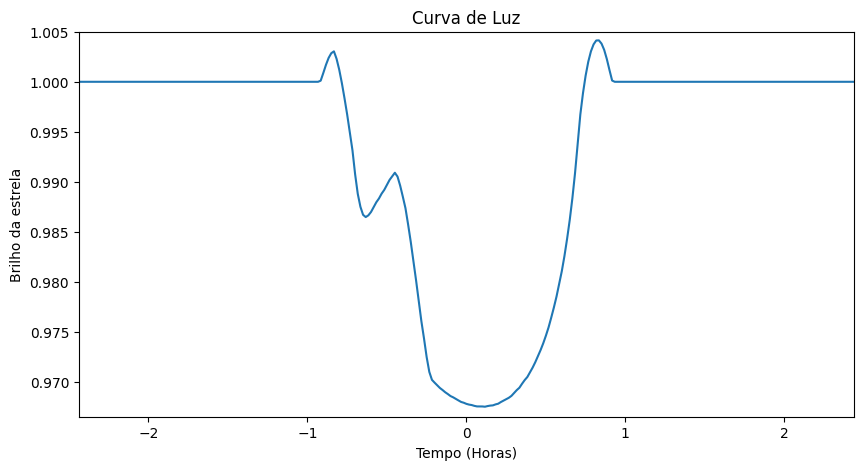

Tempo Total (Trânsito): 4.875141909426886


In [68]:
#eclipse
estrela_matriz = estrela_.getMatrizEstrela()
eclipse.setEstrela(estrela_matriz)
eclipse.criarEclipse(anim=False)

print ("Tempo Total (Trânsito):", eclipse.getTempoTransito()) 
tempoTransito = eclipse.getTempoTransito()
curvaLuz = eclipse.getCurvaLuz()
tempoHoras = eclipse.getTempoHoras()

### Isolando sinal CME 

### Funções

In [253]:
def comparar_curvas_transito(
    lc_modelo_raw,
    tempo_modelo_raw_horas, 
    fase_obs,
    fluxo_obs, 
    periodo_dias,
    mission="XMM-Newton", 
    offset_fase=0.0, 
    normalizar_baseline=False, 
    duracao_transito_horas=1.8,
    nome_salvar=None
):
    """
    Sincroniza, interpola e plota a curva de luz do modelo ECLIPSE contra os dados observacionais.
    """
    # --- 1. ALINHAR O MODELO EM FASE ORBITAL ---
    lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
    meio_transito_modelo = tempo_modelo_raw_horas[np.argmin(lc_modelo_normalizado)]
    tempo_centralizado = tempo_modelo_raw_horas - meio_transito_modelo
    periodo_horas = periodo_dias * 24.0
    
    # Aplica o offset se fornecido (ex: -0.2)
    fase_do_modelo = (tempo_centralizado + offset_fase) / periodo_horas

    # --- 2. PROCESSAMENTO DA OBSERVAÇÃO ---
    fase_obs = np.array(fase_obs)
    fluxo_obs = np.array(fluxo_obs)

    if normalizar_baseline:
        meia_duracao_fase = (duracao_transito_horas / 2.0) / periodo_horas
        mask_fora_transito = np.abs(fase_obs) > meia_duracao_fase
        fluxo_de_referencia = np.mean(fluxo_obs[mask_fora_transito])
        
        fluxo_obs_processado = fluxo_obs / fluxo_de_referencia
        label_obs = 'Curva de Luz Observada (Normalizada)'
    else:
        fluxo_obs_processado = fluxo_obs
        label_obs = 'Curva de Luz Observada'

    # --- 3. INTERPOLAÇÃO PARA EIXO COMUM ---
    fase_plot_final = np.linspace(fase_obs.min(), fase_obs.max(), 1000)
    fluxo_observado_interp = np.interp(fase_plot_final, fase_obs, fluxo_obs_processado)
    fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)

    # --- 4. PLOTAGEM ---
    plt.rcParams['figure.figsize'] = 8, 4
    fig, ax = plt.subplots()

    ax.plot(fase_plot_final, fluxo_observado_interp, "r-", label=label_obs)
    ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Modelo')

    # Formatação do Gráfico
    ax.set_xlabel("Fase Orbital (0 = Meio do Trânsito)")
    ax.set_ylabel("Fluxo Normalizado")
    ax.grid(True, linestyle='--')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

    # Retorna os arrays caso você precise salvar os dados depois
    return fase_plot_final, fluxo_observado_interp, fluxo_modelo_interp

In [77]:
def aplicar_detrending_spline(fase, fluxo, duracao_horas, periodo_horas, s=0.001, titulo="Detrending"):
    """
    Realiza o detrending de uma curva de luz ignorando a região do trânsito.
    """
    # 1. Definição da Máscara
    meia_duracao_em_fase = (duracao_horas / 2.0) / periodo_horas
    mask_fora_transito = np.abs(fase) > meia_duracao_em_fase
    
    # 2. Ajuste da Spline (Modelagem da variabilidade estelar)
    spl = UnivariateSpline(fase[mask_fora_transito], fluxo[mask_fora_transito], s=s)
    tendencia = spl(fase)
    
    # 3. Normalização (Achatamento)
    fluxo_achatado = fluxo / tendencia
    
    # 4. Plotagem
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'{titulo} com Spline', fontsize=16)

    # Painel Superior: Tendência
    axs[0].plot(fase, fluxo, 'r.', markersize=2, label='Dados Originais')
    axs[0].plot(fase[mask_fora_transito], fluxo[mask_fora_transito], 'k.', markersize=2, label='Pontos Usados (Fora do Trânsito)')
    axs[0].plot(fase, tendencia, 'c-', linewidth=3, label='Tendência (Spline)')
    axs[0].set_ylabel('Fluxo')
    axs[0].legend()
    axs[0].grid(True, linestyle='--')

    # Painel Inferior: Resultado
    axs[1].plot(fase, fluxo_achatado, 'k.', markersize=2, label='Fluxo Normalizado')
    axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
    axs[1].set_ylabel('Fluxo Normalizado')
    axs[1].legend()
    axs[1].grid(True, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    return fluxo_achatado, tendencia, meia_duracao_em_fase

### Modelo e sinal

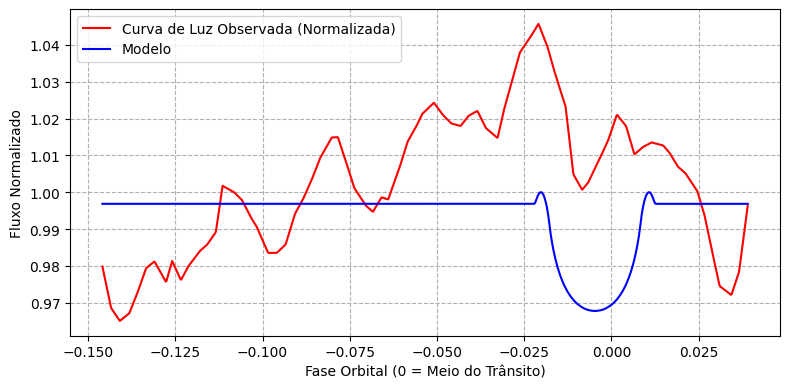

In [1008]:
fase_plot_final, fluxo_observado_interp, fluxo_modelo_interp = comparar_curvas_transito(
    lc_modelo_raw=np.array(eclipse.getCurvaLuz()),
    tempo_modelo_raw_horas=np.array(eclipse.getTempoHoras()),
    fase_obs=binned_fase_alvo,
    fluxo_obs=binned_fluxo_alvo_smooth,
    periodo_dias=periodo_geral_dias,
    mission="XMM-Newton",
    normalizar_baseline=True,
    duracao_transito_horas=1.8,
    offset_fase=-0.25  # Ajuste fino da fase aqui
)

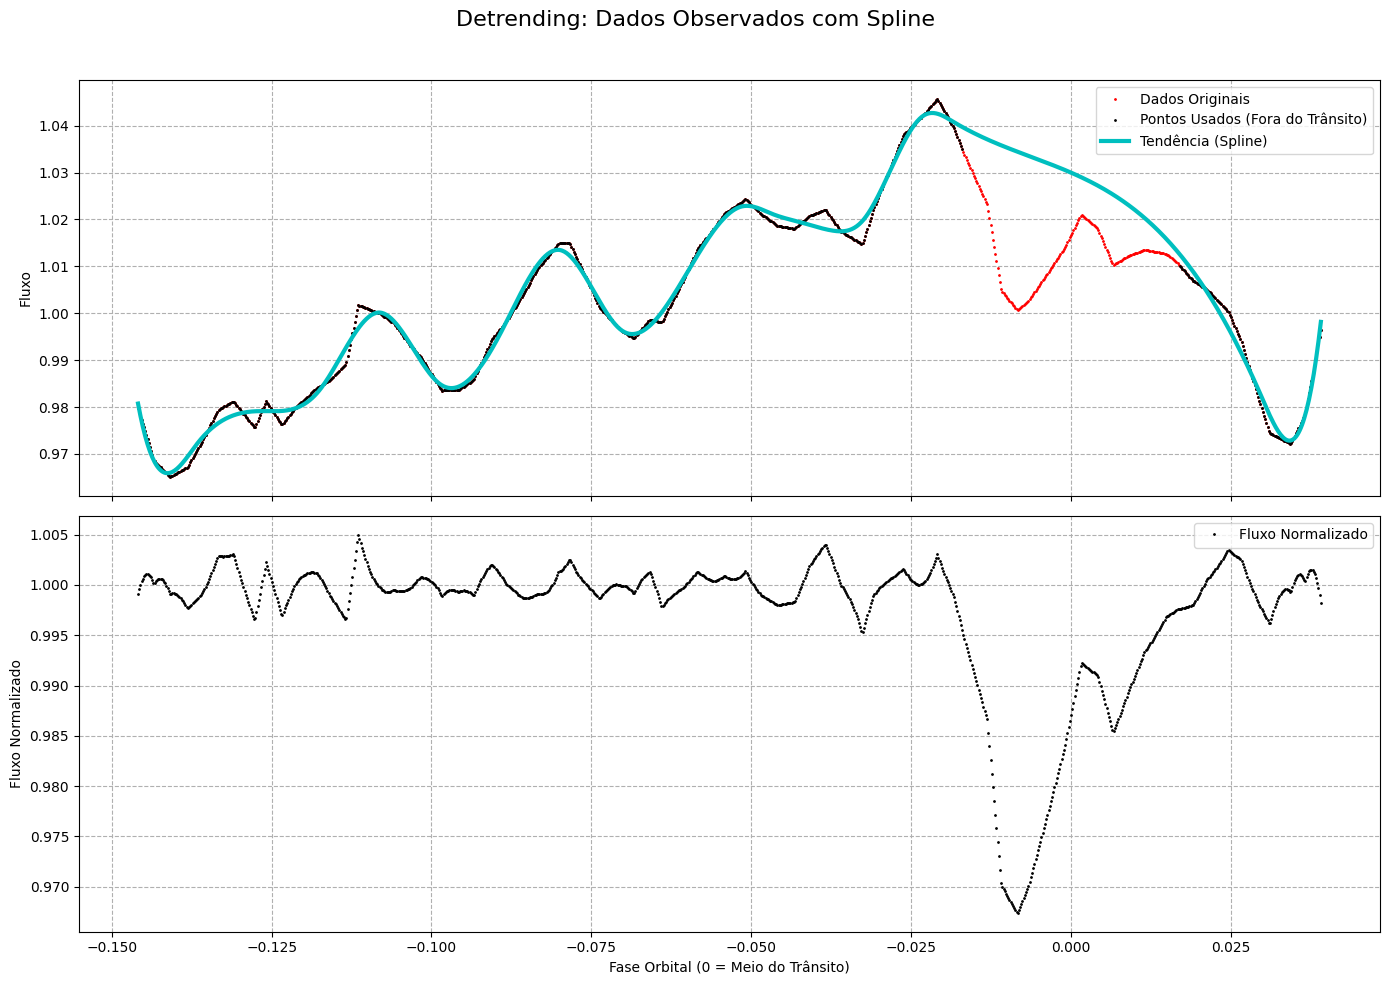

In [1009]:
# Parâmetros baseados na HD 189733A
duracao_total = 1.8
periodo_h = 2.21857520 * 24.0

fluxo_final_achatado, tendencia_obs, meia_duracao_em_fase = aplicar_detrending_spline(
    fase=fase_plot_final, 
    fluxo=fluxo_observado_interp, 
    duracao_horas=duracao_total, 
    periodo_horas=periodo_h, 
    s=0.002,
    titulo="Detrending: Dados Observados"
)

Gráfico salvo com sucesso em: products/lightcurve-with-signal.png


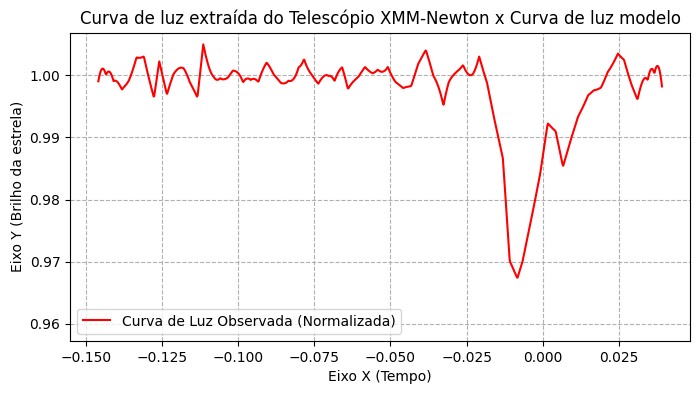

In [1010]:
# --- 4. PLOTAGEM FINAL ---
mission = "XMM-Newton"

plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

fluxo_modelo_interp = fluxo_modelo_interp + (1 - fluxo_modelo_interp[0])

# --- MUDANÇA AQUI: plotar a curva normalizada ---
ax.plot(fase_plot_final, fluxo_final_achatado, "r-", label='Curva de Luz Observada (Normalizada)')

ax.set_xlabel("Fase Orbital (0 = Meio do Trânsito)")
ax.set_ylabel("Fluxo Normalizado")
ax.grid(True, linestyle='--')

plotLegendModel(ax, mission,f"lightcurve-with-signal") 

### Comparando curva de luz observada com modelo gerado com sinal de CME adicionado

Gráfico salvo com sucesso em: products/adjust-result-capsule.png


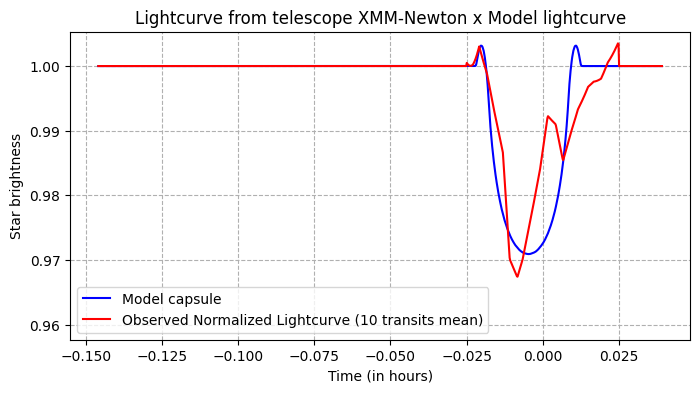

In [1011]:
# --- 4. PLOTAGEM FINAL ---
mission = "XMM-Newton"
#geometria_selecionada = "capsula" if projecao_selecionada == GeometriaCME.PROJECAO_DISCO else "gota"
geometria_selecionada = "capsule" if projecao_selecionada == GeometriaCME.PROJECAO_DISCO else "drop"


plt.rcParams['figure.figsize'] = 8, 4
graf1, ax = plt.subplots()

fluxo_modelo_interp = fluxo_modelo_interp + (1 - fluxo_modelo_interp[0])

fluxo_final_achatado_filtrado = filtrar_janela_numpy(fase_plot_final, fluxo_final_achatado, 0.025)
fluxo_final_achatado = fluxo_final_achatado_filtrado

ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label=f"Model {geometria_selecionada}")
ax.plot(fase_plot_final, fluxo_final_achatado, "r-", label='Observed Normalized Lightcurve (10 transits mean)')

ax.grid(True, linestyle='--')

plotLegendModel(ax, mission,f"adjust-result-{geometria_selecionada}", language="EN")

### Analisar ruído

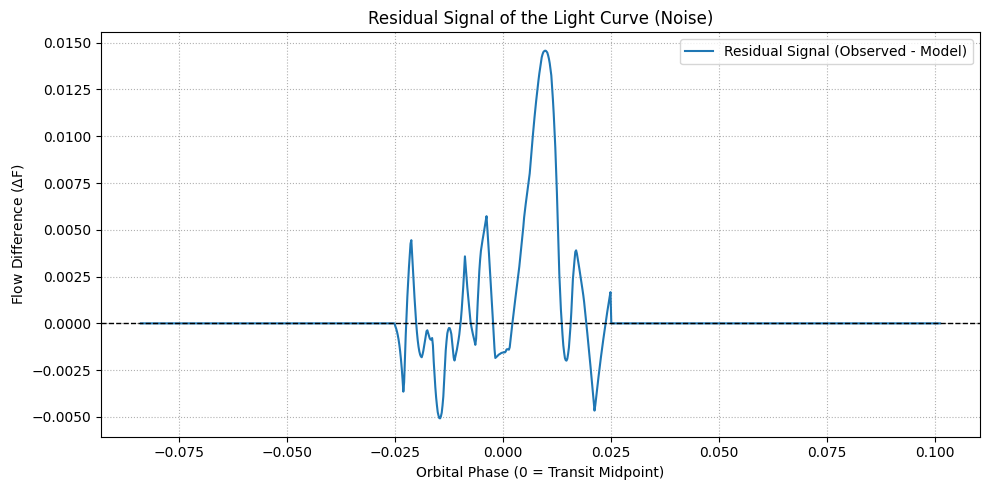

In [ ]:
# --- 1. CÁLCULO DO RUÍDO/RESIDUAL ---
# A diferença entre os dois arrays já alinhados.
# O resultado estará no eixo vertical.
ruido = fluxo_final_achatado - fluxo_modelo_interp

# --- 2. GERAÇÃO DO NOVO PLOT ---
plt.figure(figsize=(10, 5))

# # Plot do Ruído (Usando a cor verde, já que vermelho e azul foram usados)
# plt.plot(fase_plot_final, ruido, "-", label='Sinal Residual (Observado - Modelo)')

# # Linha de referência no zero (Baseline)
# # Esta linha é essencial, pois qualquer desvio dela representa um sinal anômalo.
# plt.axhline(0, color='black', linestyle='--', linewidth=1)

# # Configuração do Gráfico
# plt.title("Sinal Residual da Curva de Luz (Ruído)")
# plt.xlabel("Fase Orbital (0 = Meio do Trânsito)")
# plt.ylabel("Diferença de Fluxo ($\Delta$F)")
# plt.legend()
# plt.grid(True, linestyle=':')
# plt.tight_layout()

# Plot of Noise (Using green, since red and blue were used)
plt.plot(fase_plot_final, ruido, "-", label='Residual Signal (Observed - Model)')

# Baseline at zero
# This line is essential, as any deviation from it represents an anomalous signal.

plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Graph Configuration
plt.title("Residual Signal of the Light Curve (Noise)")
plt.xlabel("Orbital Phase (0 = Transit Midpoint)")
plt.ylabel("Flow Difference ($\Delta$F)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()

# Salvar a figura
fig_name = "fig-sinal-residual-model"
output_dir = 'products'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, f"{fig_name}.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

In [963]:
def calcular_rms(sinal_residual):
    """Calcula o Root Mean Square (RMS) do sinal residual."""
    # Fórmula: Raiz quadrada da média dos quadrados.
    return np.sqrt(np.mean(sinal_residual**2))

In [977]:
rms_modelado = calcular_rms(ruido)

print(f"RMS Modelo {geometria_selecionada}: {rms_modelado:.5f}")

RMS Modelo capsule: 0.00265


## Ajustes

In [431]:
from Adjust.Adjust import AjusteCME, AjusteManchado
from Adjust.Model import Modelo
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt
import numpy as np

### Função para plots de resultados

In [494]:
def gera_curva_CME(parametros_modelo, theta, binned_fase_alvo, binned_fluxo_alvo_smooth, cme: Estrela.EjecaoMassa, offset_fase=-0.2):
    print("theta", theta)
    # Parâmetros resultados no primeiro mcmc 
    u1 = parametros_modelo['u1']
    u2 = parametros_modelo['u2']
    semi_eixo_UA = parametros_modelo['semi_eixo_UA']
    angulo_inclinacao = parametros_modelo['angulo_inclinacao']
    raio_plan_Jup = parametros_modelo['raio_plan_Jup']

    estrela_ = Estrela(373, parametros_modelo['rsun'], 240., u1, u2, 856)
    estrela_.setStarName("HD189733 A")
    estrela_.setCadence("fast")

    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_= Planeta(semi_eixo_UA, raio_plan_Jup, parametros_modelo['periodo'], angulo_inclinacao, 0, 0, estrela_.getRaioSun(), parametros_modelo['mass_planeta'])

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_)
    eclipse.setTempoHoras(5)

    estrela_.criaEstrelaComFaculas()
    estrela_matriz = estrela_.getMatrizEstrela()

    temperatura_cme = estrela_.temperaturaEfetiva-800
    raio_cme = int(theta[0]) # em ??
    velocidade_cme = theta[6] #tempo = d / v_CME
    opacidade = theta[5]
    p0x = int(theta[1]) 
    p0y = int(theta[2]) 
    p1x = int(theta[3])
    p1y = int(theta[4]) 
    taxa_esurecimento = theta[7]
    cme = Estrela.EjecaoMassa(raio_cme, p0x, p0y, p1x, p1y, opacidade, temperatura_cme, velocidade_cme, taxa_esurecimento, cme.altura_inicial, GeometriaCME.PROJECAO_DISCO)


    print("raio_cme: ", raio_cme)
    print("velocidade_cme: ", velocidade_cme)
    print("opacidade: ", opacidade)
    print("p0x: ", p0x)
    print("p0y: ", p0y)
    print("p1x: ", p1x)
    print("p1y: ", p1y)
    print("taxa_escurecimento: ", taxa_esurecimento)

    estrela_.addCme(cme)
    #estrela_.ejecaoDeMassa(temperatura_cme, raio_cme)

    #eclipse
    estrela_matriz = estrela_.getMatrizEstrela()
    eclipse.setEstrela(estrela_matriz)
    eclipse.criarEclipse(anim=False)

    print ("Tempo Total (Trânsito):", eclipse.getTempoTransito()) 

    lc_modelo_raw = np.array(eclipse.getCurvaLuz()) 
    tempo_modelo_raw_horas = np.array(eclipse.getTempoHoras())

    # --- 2. ALINHAR O MODELO EM FASE ORBITAL ---
    lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
    meio_transito_no_modelo_horas = tempo_modelo_raw_horas[np.argmin(lc_modelo_normalizado)]
    tempo_modelo_centralizado = tempo_modelo_raw_horas - meio_transito_no_modelo_horas
    periodo_em_horas = periodo_geral_dias * 24.0
    fase_do_modelo = (tempo_modelo_centralizado - offset_fase ) / periodo_em_horas  # ajustar aqui o alinhamento

    # --- 3. INTERPOLAR AMBAS AS CURVAS PARA UM EIXO COMUM ---
    # Primeiro, garantimos que as listas dos dados observados sejam arrays NumPy
    #binned_fase_alvo, binned_fluxo_alvo_smooth
    binned_fase_alvo = np.array(binned_fase_alvo)
    binned_fluxo_alvo_smooth = np.array(binned_fluxo_alvo_smooth)
    # -----------------------------

    fase_plot_final = np.linspace(binned_fase_alvo.min(), binned_fase_alvo.max(), 1000)

    # Mapeamos (interpolamos) a curva de luz observada para o novo eixo
    fluxo_observado_interp = np.interp(fase_plot_final, binned_fase_alvo, binned_fluxo_alvo_smooth)

    # Mapeamos (interpolamos) a curva de luz do seu modelo para o novo eixo
    fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)

    # --- 4. PLOTAGEM FINAL CORRIGIDA ---
    plt.rcParams['figure.figsize'] = 8, 4
    graf1, ax = plt.subplots()

    mission = "XMM-Newton"

    fluxo_modelo_interp = fluxo_modelo_interp + (1 - fluxo_modelo_interp[0])

    ax.plot(fase_plot_final, fluxo_final_achatado, "r-", label='Normalized Observed Lightcurve')
    ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Model')
    plotLegendModel(ax, mission, "result-mcmc", "EN") 
    return fluxo_modelo_interp, fluxo_final_achatado

In [239]:
def plot_detrending_modelo(fase_plot_final, fluxo_modelo_interp_result, meia_duracao_em_fase): 
    # 2. Criar uma máscara para selecionar apenas os pontos FORA do trânsito
    mask_fora_transito = np.abs(fase_plot_final) > meia_duracao_em_fase

    # 3. Ajustar a Spline USANDO APENAS os dados de fora do trânsito
    # Isso ensina à Spline qual é a tendência de "eventos" da estrela
    spl = UnivariateSpline(fase_plot_final[mask_fora_transito], fluxo_modelo_interp_result[mask_fora_transito], s=0.001)

    # 4. Gerar a curva de tendência para TODOS os pontos de tempo
    tendencia_spline_modelo = spl(fase_plot_final)

    # 5. Normalizar: Dividir a curva de luz original pela tendência encontrada
    fluxo_final_achatado_modelo = fluxo_modelo_interp_result / tendencia_spline_modelo

    # --- 3. PLOTAGEM DOS RESULTADOS ---
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Detrending da Curva de Luz com Spline', fontsize=16)

    # Painel Superior: O Ajuste da Tendência
    axs[0].plot(fase_plot_final, fluxo_modelo_interp_result, 'r.', markersize=2, label='Dados Originais')
    axs[0].plot(fase_plot_final[mask_fora_transito], fluxo_modelo_interp_result[mask_fora_transito], 'k.', markersize=2, label='Dados Fora do Trânsito (usados no ajuste)')
    axs[0].plot(fase_plot_final, tendencia_spline_modelo, 'c-', linewidth=3, label='Tendência (Spline)')
    axs[0].set_title('Passo 1: Modelando a Variabilidade Fora do Trânsito')
    axs[0].set_ylabel('Fluxo')
    axs[0].legend()
    axs[0].grid(True, linestyle='--')

    # Painel Inferior: O Resultado fluxo_final_achatado_modelo
    axs[1].plot(fase_plot_final, fluxo_final_achatado_modelo, 'k-', markersize=2, label='Curva de Luz Achatada (Normalizada)')
    axs[1].plot(fase_plot_final, fluxo_final_achatado, 'r.', markersize=2, label='Dados média de 10 trânsitos' )
    axs[1].set_title('Passo 2: Resultado Final Uniforme')
    axs[1].set_xlabel('Fase Orbital (0 = Meio do Trânsito)')
    axs[1].set_ylabel('Fluxo Normalizado')
    axs[1].legend()
    axs[1].grid(True, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fluxo_final_achatado_modelo

### Detrending dos dados observados

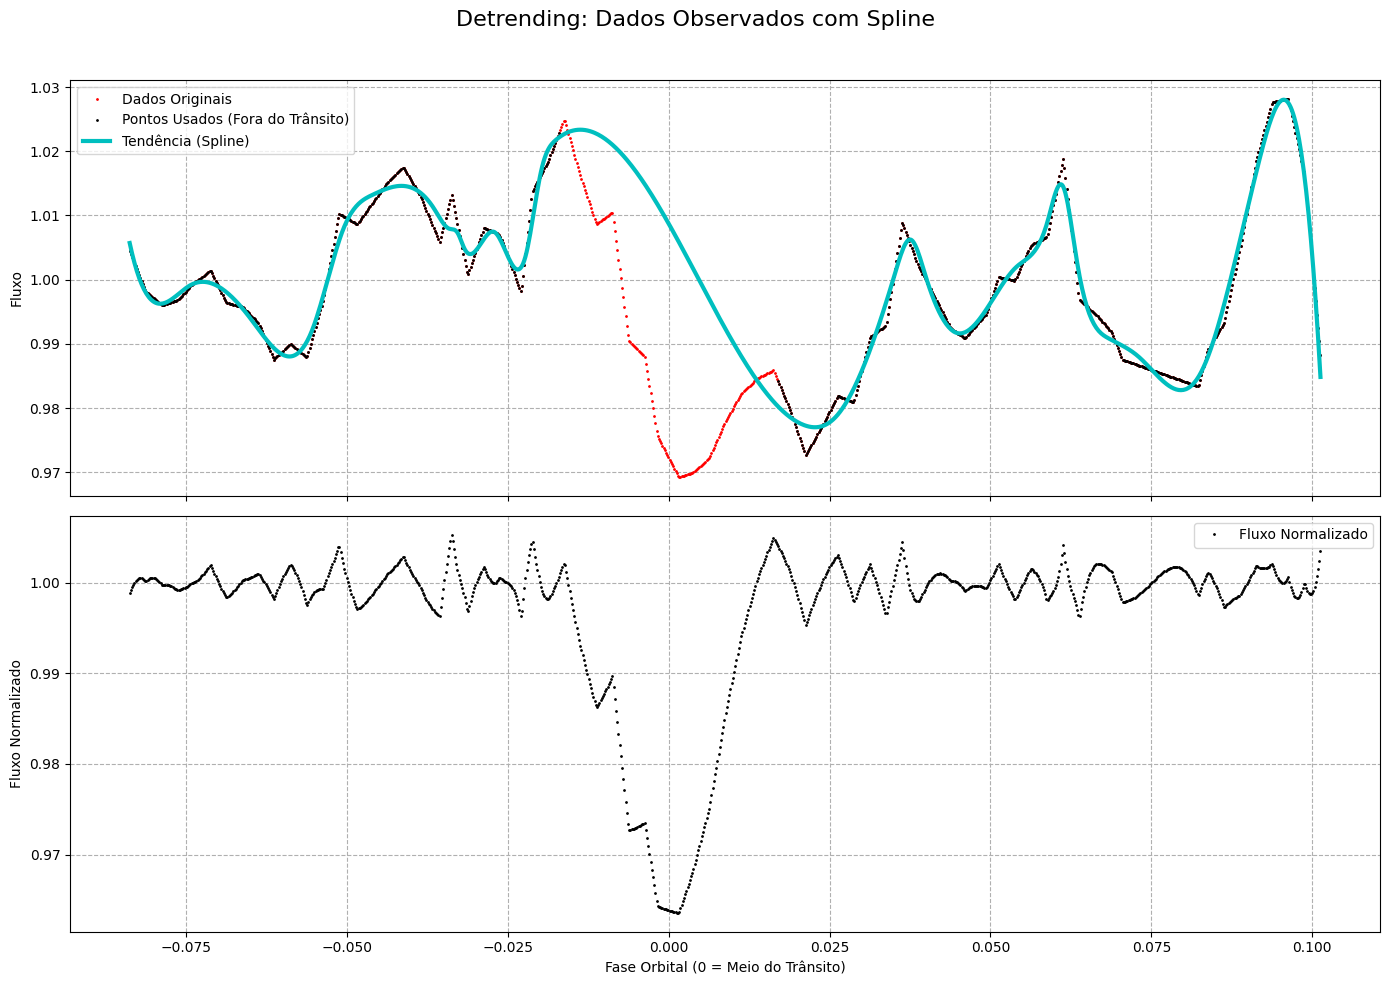

In [432]:
# Parâmetros baseados na HD 189733A
duracao_total = 1.8
periodo_h = 2.21857520 * 24.0

fluxo_final_achatado, tendencia_obs, meia_duracao_em_fase = aplicar_detrending_spline(
    fase=fase_plot_final, 
    fluxo=fluxo_observado_interp, 
    duracao_horas=duracao_total, 
    periodo_horas=periodo_h, 
    s=0.002,
    titulo="Detrending: Dados Observados"
)

### Ajuste para CME

In [749]:
nwalkers = 30
niter = 30
burnin = 15
ndim = 1

modelo = Modelo(estrela_, eclipse, "XMM-Newton")

fluxo_final_achatado_comparar = fluxo_final_achatado - (1 - fluxo_modelo_interp[0])

# fluxo_modelo_interp 
ajusteCME = AjusteCME(modelo, fase_plot_final*50, fluxo_final_achatado_comparar, nwalkers, niter, burnin, ndim, eclipse, cme, parametros_modelo['rsun'], parametros_modelo['periodo'])

time = fase_plot_final
flux = fluxo_final_achatado

In [750]:
sampler, pos, prob, state = ajusteCME.main()

Running burn-in...


100%|██████████| 15/15 [00:00<00:00, 802.27it/s]


Running production...


100%|██████████| 30/30 [00:00<00:00, 907.33it/s]


In [751]:
samples = sampler.flatchain
samples[np.argmax(sampler.flatlnprobability)]

array([9.00000000e+01, 2.89000000e+02, 2.19000000e+02, 2.00000000e+02,
       2.70000000e+02, 4.98148243e-01, 1.49295606e-01, 1.49891699e+02])

In [752]:
theta_max  = samples[np.argmax(sampler.flatlnprobability)]
print(theta_max)
best_fit_model = ajusteCME.eclipse_mcmc(time, theta_max)

[9.00000000e+01 2.89000000e+02 2.19000000e+02 2.00000000e+02
 2.70000000e+02 4.98148243e-01 1.49295606e-01 1.49891699e+02]


theta [9.00000000e+01 2.89000000e+02 2.19000000e+02 2.00000000e+02
 2.70000000e+02 4.98148243e-01 1.49295606e-01 1.49891699e+02]
raio_cme:  90
velocidade_cme:  0.14929560610465129
opacidade:  0.49814824257691925
p0x:  289
p0y:  219
p1x:  200
p1y:  270
taxa_escurecimento:  149.89169881698845
0.603186845779419


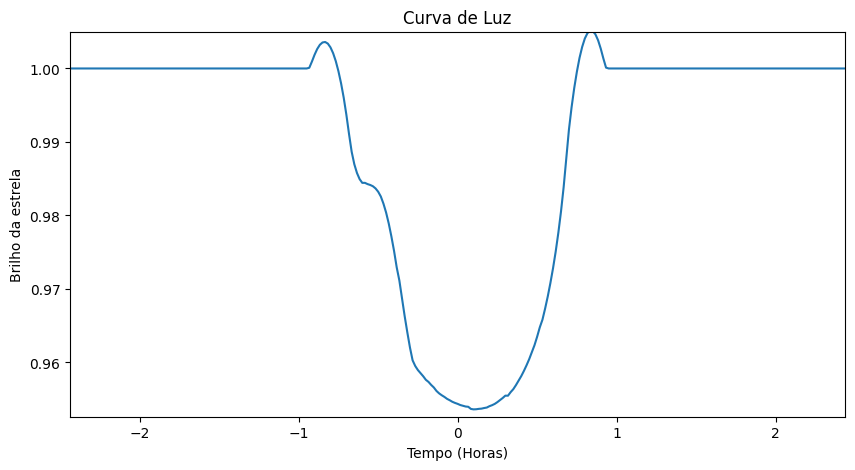

Tempo Total (Trânsito): 4.875141909426886
Gráfico salvo com sucesso em: products/result-mcmc.png


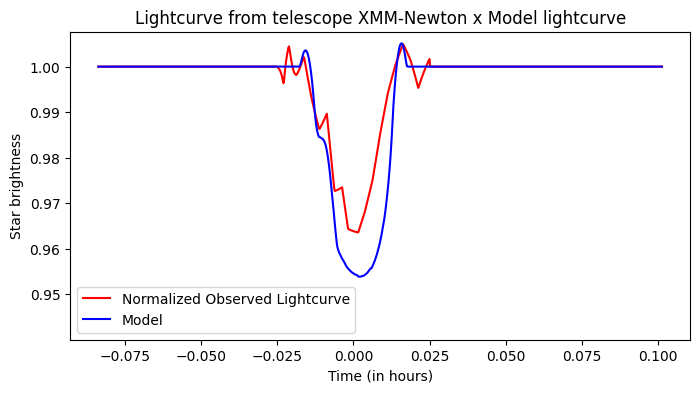

In [753]:
fluxo_modelo_interp_result, fluxo_final_achatado = gera_curva_CME(parametros_modelo, theta_max, binned_fase_alvo, binned_fluxo_alvo_smooth, cme, -0.1)

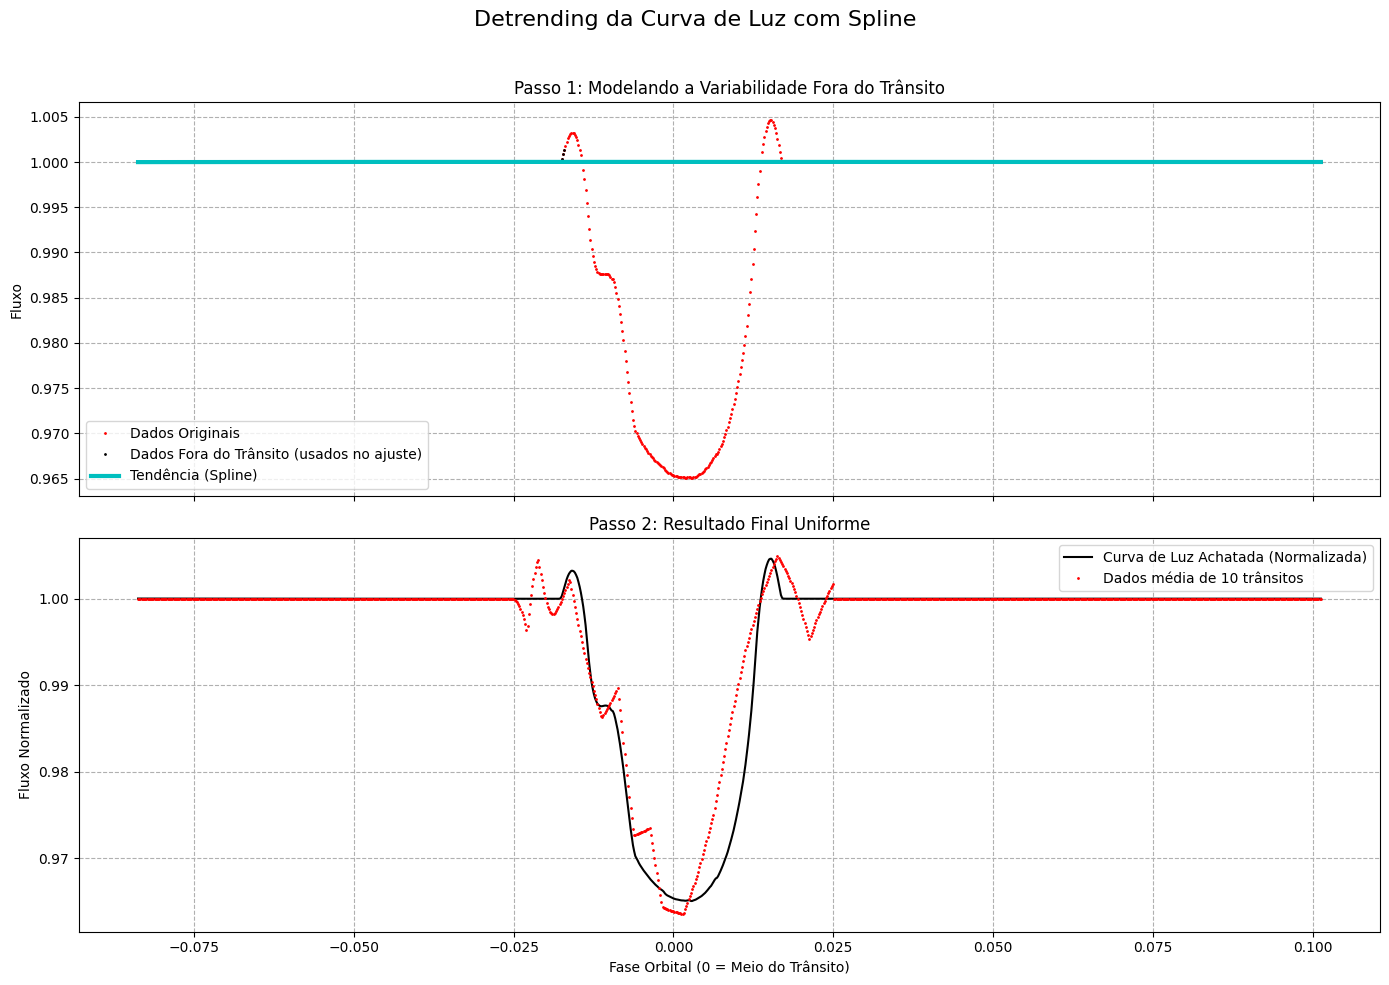

In [456]:
fluxo_final_achatado_modelo = plot_detrending_modelo(fase_plot_final, fluxo_modelo_interp_result, meia_duracao_em_fase)

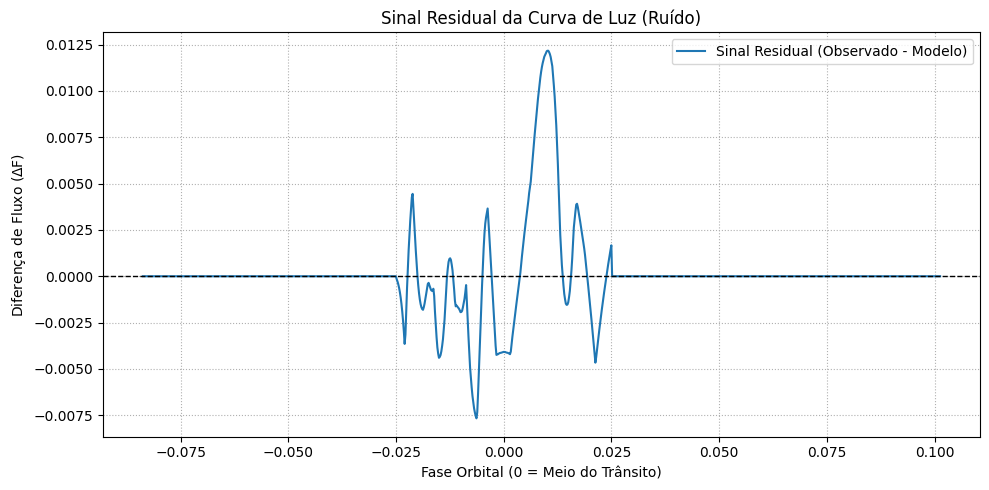

In [ ]:
# --- 1. CÁLCULO DO RUÍDO/RESIDUAL ---
# A diferença entre os dois arrays já alinhados.
# O resultado estará no eixo vertical.
ruido_ajuste =  fluxo_final_achatado - fluxo_final_achatado_modelo

# --- 2. GERAÇÃO DO NOVO PLOT ---
plt.figure(figsize=(10, 5))

# Plot do Ruído (Usando a cor verde, já que vermelho e azul foram usados)
plt.plot(fase_plot_final, ruido, "-", label='Sinal Residual (Observado - Modelo)')

# Linha de referência no zero (Baseline)
# Esta linha é essencial, pois qualquer desvio dela representa um sinal anômalo.
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Configuração do Gráfico
plt.title("Sinal Residual da Curva de Luz (Ruído)")
plt.xlabel("Fase Orbital (0 = Meio do Trânsito)")
plt.ylabel("Diferença de Fluxo ($\Delta$F)")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()

# Salvar a figura
fig_name = "fig-sinal-residual-fit"
output_dir = 'products'
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, f"{fig_name}.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

In [461]:
rms_ajustado = calcular_rms(ruido_ajuste)

print(f"RMS Modelado {geometria_selecionada}: {rms_modelado:.5f}")
print(f"RMS Ajustado {geometria_selecionada}: {rms_ajustado:.5f}")

RMS Modelado gota: 0.00233
RMS Ajustado gota: 0.00266


### Ajuste mancha
Caso queira analisar o sinal utilizando a modelagem simples da mancha utilize o script abaixo

In [299]:
nwalkers = 30
niter = 30
burnin = 15
ndim = 1

fluxo_final_achatado_comparar = fluxo_final_achatado - (1 - fluxo_modelo_interp[0])

ajusteManchado = AjusteManchado(modelo, fase_plot_final*50, fluxo_final_achatado_comparar, nwalkers, niter, burnin, ndim, eclipse, parametros_modelo['rsun'], parametros_modelo['periodo'])

time = fase_plot_final
flux = fluxo_final_achatado

In [300]:
sampler, pos, prob, state = ajusteManchado.main()

Running burn-in...


100%|██████████| 15/15 [04:16<00:00, 17.09s/it]


Running production...


100%|██████████| 30/30 [08:41<00:00, 17.37s/it]


In [301]:
samples = sampler.flatchain
samples[np.argmax(sampler.flatlnprobability)]

array([ 10.29264498, -12.83613276,   0.27105426,   0.09390377])

In [302]:
theta_max  = samples[np.argmax(sampler.flatlnprobability)]
print(theta_max)
best_fit_model = ajusteManchado.eclipse_mcmc(time, theta_max)

[ 10.29264498 -12.83613276   0.27105426   0.09390377]


In [303]:
def plotLegendAdjust(plot, mission): 
    # Adicionando título e legendas dos eixos
    plot.title(f'Curva de luz extraída do Telescópio {mission} x Curva de luz ajustada')
    plot.xlabel('Eixo X (Tempo)')
    plot.ylabel('Eixo Y (Brilho da estrela)')

    # Exibindo a legenda
    plot.legend()
    plot.show()

In [304]:
def gera_curva_mancha(parametros_modelo, theta, binned_fase_alvo, binned_fluxo_alvo_smooth):
    # Parâmetros resultados no primeiro mcmc 
    u1 = parametros_modelo['u1']
    u2 = parametros_modelo['u2']
    semi_eixo_UA = parametros_modelo['semi_eixo_UA']
    angulo_inclinacao = parametros_modelo['angulo_inclinacao']
    raio_plan_Jup = parametros_modelo['raio_plan_Jup']

    estrela_ = Estrela(373, parametros_modelo['rsun'], 240., u1, u2, 856)
    estrela_.setStarName("HD189733 A")
    estrela_.setCadence("fast")

    Nx = estrela_.getNx()
    Ny = estrela_.getNy()
    raioEstrelaPixel = estrela_.getRaioStar()

    planeta_= Planeta(semi_eixo_UA, raio_plan_Jup, parametros_modelo['periodo'], angulo_inclinacao, 0, 0, estrela_.getRaioSun(), parametros_modelo['mass_planeta'])

    eclipse = Eclipse(Nx, Ny, raioEstrelaPixel, estrela_, planeta_)
    eclipse.setTempoHoras(5)

    # add mancha
    for i in range(0, len(theta), 4):
        longitude_mancha = theta[i+0]
        latitude_mancha = theta[i+1]
        raio_mancha = theta[i+2]
        intensidade_mancha = theta[i+3]

        mancha = Estrela.Mancha(intensidade_mancha, raio_mancha, latitude_mancha, longitude_mancha)
        #facula2 = Estrela.Facula(1.5, 0.08, latitude_facula, longitude_facula) #caso queira adicionar mais fáculas


        estrela_.addMancha(mancha)
        #estrela_.addFacula(facula2)

    estrela_.criaEstrelaManchada()
    estrela_matriz = estrela_.getMatrizEstrela()

    estrela_matriz = estrela_.getMatrizEstrela()

    #eclipse
    estrela_matriz = estrela_.getMatrizEstrela()
    eclipse.setEstrela(estrela_matriz)
    eclipse.criarEclipse(anim=False)

    print ("Tempo Total (Trânsito):", eclipse.getTempoTransito()) 
    tempoTransito = eclipse.getTempoTransito()
    curvaLuz = eclipse.getCurvaLuz()
    tempoHoras = eclipse.getTempoHoras()

    lc_modelo_raw = np.array(eclipse.getCurvaLuz()) 
    tempo_modelo_raw_horas = np.array(eclipse.getTempoHoras())

    # --- 2. ALINHAR O MODELO EM FASE ORBITAL ---
    lc_modelo_normalizado = lc_modelo_raw / np.max(lc_modelo_raw)
    meio_transito_no_modelo_horas = tempo_modelo_raw_horas[428]
    tempo_modelo_centralizado = tempo_modelo_raw_horas - meio_transito_no_modelo_horas
    periodo_em_horas = periodo_geral_dias * 24.0
    fase_do_modelo = (tempo_modelo_centralizado) / periodo_em_horas

    # --- 3. INTERPOLAR AMBAS AS CURVAS PARA UM EIXO COMUM ---
    # Primeiro, garantimos que as listas dos dados observados sejam arrays NumPy
    #binned_fase_alvo, binned_fluxo_alvo_smooth
    binned_fase_alvo = np.array(binned_fase_alvo)
    binned_fluxo_alvo_smooth = np.array(binned_fluxo_alvo_smooth)
    # -----------------------------

    fase_plot_final = np.linspace(binned_fase_alvo.min(), binned_fase_alvo.max(), 1000)

    # Mapeamos (interpolamos) a curva de luz observada para o novo eixo
    fluxo_observado_interp = np.interp(fase_plot_final, binned_fase_alvo, binned_fluxo_alvo_smooth)

    # Mapeamos (interpolamos) a curva de luz do seu modelo para o novo eixo
    fluxo_modelo_interp = np.interp(fase_plot_final, fase_do_modelo, lc_modelo_normalizado)

    # --- 4. PLOTAGEM FINAL CORRIGIDA ---
    plt.rcParams['figure.figsize'] = 8, 4
    graf1, ax = plt.subplots()

    mission = "HUBBLE"

    fluxo_modelo_interp = fluxo_modelo_interp + (1 - fluxo_modelo_interp[0])
    ax.plot(fase_plot_final, fluxo_final_achatado, "r-", label='Curva de Luz Observada (Normalizada)')
    ax.plot(fase_plot_final, fluxo_modelo_interp, "b-", label='Modelo')
    plotLegendModel(ax, mission) 

0.3248329162597656


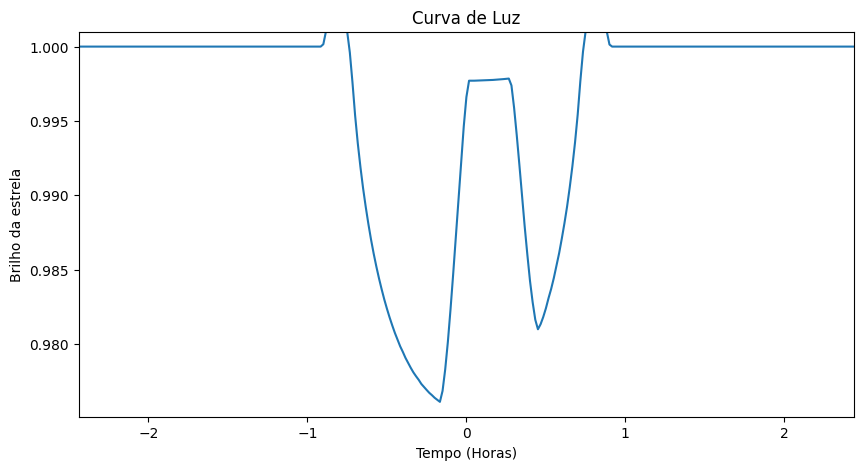

Tempo Total (Trânsito): 4.875141909426886


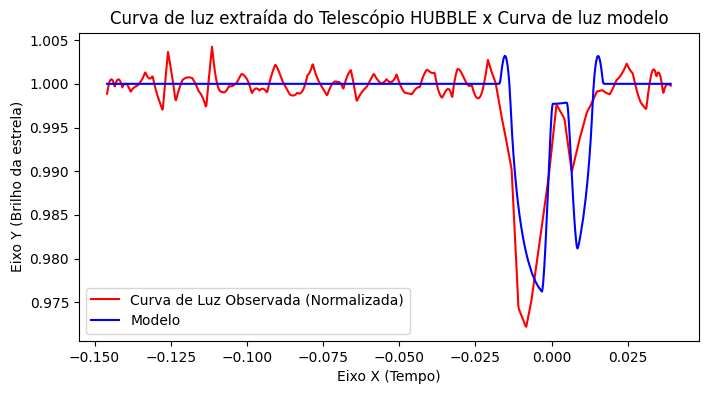

In [305]:
gera_curva_mancha(parametros_modelo, theta_max, binned_fase_alvo, binned_fluxo_alvo_smooth)